# Gravitational Sonar
### Abstract: We present an algorithm -- which, if successful -- would be capable of predicting an approximate spacetime metric for a binary black hole system to within $<1\%$ error of the innermost-stable circular orbit (ISCO). Our algorithm, coined Gravitational Sonar, is valid in the Extreme-Mass Ratio Inspiral (EMRI) limit wherein $m_1>>m_2$. We will validate our algorithm for the Schwarzschild, Kerr, and Johannsen Metrics. We will demonstrate that the algorithm can be employed on LISA waveforms with noise $\sigma>0.05$ to test the No-Hair Theorem and probe for beyond-GR corrections.

# Library Installations

In [1]:
pip install pytearcat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.6 MB/s eta 0:00:00


In [2]:
pip install torch

In [3]:
pip install torchdiffeq

In [4]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import math
from torchdiffeq import odeint

In [5]:
import pytearcat as pt

In [6]:
!wget -q https://raw.githubusercontent.com/EliKiani/Optimizing_the_Optimizer_PINNs/main/_optimize.py

In [7]:
!sed -i 's/^from \.\([a-zA-Z_]*\) import/from scipy.optimize.\1 import/' _optimize.py

In [8]:
pip install torch torchdiffeq

In [9]:
pip install xitorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.9/117.9 kB 4.8 MB/s eta 0:00:00


In [10]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
from scipy.optimize import minimize as minimize_ssbroyden

In [11]:
!grep -n "^def _minimize_bfgs" _optimize.py

1415:def _minimize_bfgs(fun, x0, args=(), jac=None, callback=None,


In [12]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize  # vanilla dispatcher — now calls the patched BFGS internals

# Import Gravitational Waveforms

We import gravitational waves which were created using a Numerical Kludge orbit-to-waveform mapping forward algorithm (i.e., Quadrupole Approximation + Kerr Geodesics). For a test case, we import just one gravitational wave (technically, there are two polarizations $h_+$ and $h_\times$, so there's two).

Things to test:
- Upgrade from 1 to 3 sets of waveforms, generated by observing the same geodesic from three perspectives (testing the idea of "GPS for Black Holes")
- Since $h_\times \to 0$ as $\theta \to \pi/2$, it may be interesting to try weighting edge-on observers differently than face-on observers to see if it increases the "signal" for numerically smaller components of the Kerr metric
- Not all metric components are created equal: They may not contribute equally to the waveform, so it's important to know which ones contribute the most or least. (Perhaps this would be a so-called "Fisher Analysis" to identify potential sloppy valleys)

θ_obs: pi/4
|h1|_min: tensor(2.3903e-05)
|h1|_max: tensor(1.4579)


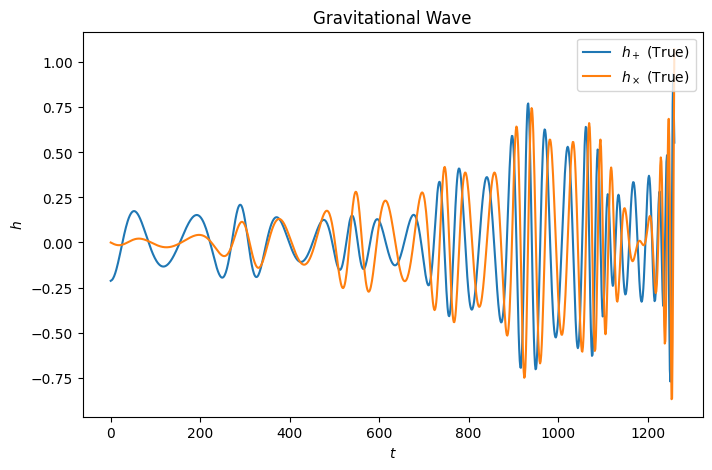

In [13]:
t_true, h_plus_true_obs1 = np.loadtxt('/content/waveform_real_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)
t_true, h_cross_true_obs1 = np.loadtxt('/content/waveform_imag_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)
soln_true = np.loadtxt('/content/solution_Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483.txt', unpack = True)

h_plus_true_obs1 = torch.tensor(h_plus_true_obs1, dtype = torch.float32)
h_cross_true_obs1 = torch.tensor(h_cross_true_obs1, dtype = torch.float32)

print("θ_obs: pi/4")
print("|h1|_min:", min(h_plus_true_obs1**2 + h_cross_true_obs1**2))
print("|h1|_max:", max(h_plus_true_obs1**2 + h_cross_true_obs1**2))

fig, ax = plt.subplots(figsize=(8,5))
plt.plot(t_true, h_plus_true_obs1, label = r"$h_+$ (True)")
plt.plot(t_true, h_cross_true_obs1, label = r"$h_\times$ (True)")
plt.legend(loc = "upper right")
plt.xlabel(r'$t$')
plt.ylabel(r'$h$')
plt.title('Gravitational Wave')
plt.show()

# Input Parameters

The neural network is supplied with the exact orbital parameters (and thus, supplied with the correct initial conditions).

Things to test:
- Approach 1: A curriculum-based approach where one chops up the waveform into many pieces and iteratively trains on larger sections of the waveform (i.e., increase `t_test` from `[:600]` to `[:1200]` to `[:2000]`)
- Approach 2: Train on the entire waveform from the start, but iteratively sample the waveform with more points (i.e., increase `t_test` from `[::40]` to `[::100]` to `[::500]`)

In [14]:
rp_true = 10
ra_true = 14
a_true = 0.9
θmin_true = math.pi/4
θ_observed = [math.pi/4]

In [15]:
t = torch.linspace(0, 1260, 1000)
t_final = 1260
t_test = t[:t_final]

print(len(t))
print(len(t_test))

1000
1000


In [16]:
h_plus_true = [h_plus_true_obs1[:t_final]]
h_cross_true = [h_cross_true_obs1[:t_final]]

# Neural Network

Build the neural network to be extremely small and simple (for starters).

Things to test:
- Increase neural network dimensions (although historically, this should be a last resort)
- Try different network architechtures (i.e., hourglass)
- Try different activation functions (i.e., ReLU, SiLU, etc.)
- Try different neural network inputs (i.e., [log(r), Θ] instead of [r, Θ])

In [17]:
import torch

class NN_Metric(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = torch.nn.Linear(2, 8) # 2 inputs -> 8 hidden features
    self.act = torch.nn.SiLU()       # non-linear hidden transform
    self.fc2 = torch.nn.Linear(8, 5) # 8 hidden features -> 5 metric fields

  def forward(self, x):
    hidden = self.act(self.fc1(x))
    return self.fc2(hidden)

In [18]:
def nn_input(r, θ):
  return torch.stack([
      1/r,
      torch.cos(θ).square()
  ])

In [19]:
torch.manual_seed(0)
net = NN_Metric()
x = torch.tensor([2.0, 1.57])
out = net(x)
print(out)

tensor([-0.0663, -0.2923, -0.1640,  0.0423,  0.4105], grad_fn=<ViewBackward0>)


In [20]:
def Kerr(x, a, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  Δ = r**2 - 2*M*r + a**2
  Σ = r**2 + a**2 * (torch.cos(θ))**2
  A = (r**2 + a**2)**2 - Δ * a**2 * (torch.sin(θ))**2
  g_tt = -(1-2*M*r/Σ)
  g_rr = Σ/Δ
  g_θθ = Σ
  g_ϕϕ = A/Σ * (torch.sin(θ))**2
  g_tϕ = (-2*M*r/Σ) * a * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, g_tϕ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tϕ, zero, zero, g_ϕϕ])
  kerr = torch.stack([row1, row2, row3, row4])
  return kerr

def g_Kerr(r, θ, M=1.0, a=a_true):

  Σ = lambda r, θ: r**2 + (a**2)*(torch.cos(θ))**2
  Δ = lambda r, θ: r**2 - 2*M*r + a**2
  A = (r**2 + a**2)**2 - Δ(r, θ) * a**2 * (torch.sin(θ))**2

  g_tt = - (1 - 2*M*r / Σ(r, θ))
  g_rr = Σ(r, θ) / Δ(r, θ)
  g_θθ = Σ(r, θ)
  g_φφ = A / Σ(r, θ) * (torch.sin(θ))**2
  g_tφ = - (2*M*r / Σ(r, θ)) * a * (torch.sin(θ))**2

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

# Ansatz

This ansatz was designed very carefully with a two-scale approach in mind:
- The ansatz must approach the correct far-field Minkowski flat spacetime limit as $r\to ∞$
- The ansatz should respect any poles or be able to represent any divergences or blow-ups in metric components as $r\to r_+$ (Outer Event Horizon of Kerr). Examples: $g_{tt}=0$ is the Ergosphere, $g^{rr}=0$ is the Event Horizon, $g_{\theta\theta}=0$ is the Singularity, and $-g_{t\phi}/g_{\phi\phi}=\omega$
- As $r\to r_+$ during the inspiral, frame-dragging should cause the second, smaller black hole to orbit the central black hole at $\Omega \to \Omega_H$, the horizon's own angular spin rate. This should be reflected in the gravitational wave frequency, which is twice that of the orbital frequency. Thus, the gravitational wave frequency at the peak amplitude should directly tell us the size of the event horizon for the massive, central black hole. I believe that this deduction holds only for EMRIs (Extreme-Mass Ratio Inspirals), where the smaller, secondary black hole can be treated as a particle on a geodesic around the larger black hole.
- The ansatz is inspired by a post-newtonian expansion, with the 0th-order $O(g^0)$ term being flat, Minkowski spacetime; the 1st-order term $O(g^1)$ is Schwarzschild spacetime; the 2nd-order term $O(g^2)$ is Kerr spacetime; the 3rd-order term $O(g^3)$ or beyond would be corrections to Kerr or beyond-GR, ideally, although the ansatz does not have this yet perhaps.
- Try using `ln(r)` as an input for the neural network?

In [21]:
import torch.nn.functional as F

def NN_Ansatz(r, θ, NN):
  u = 1 / r

  g_tt = -1 + u * NN[0]
  g_rr_inv = 1 + u * NN[1]
  g_rr = 1 / g_rr_inv
  g_θθ = r**2 + NN[2]
  g_φφ = torch.sin(θ)**2 * (r**2 + NN[3])
  g_tφ = u * torch.sin(θ)**2 * NN[4]

  zero = torch.tensor(0.)
  row1 = torch.stack([g_tt, zero, zero, g_tφ])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([g_tφ, zero, zero, g_φφ])
  return torch.stack([row1, row2, row3, row4])

In [22]:
GTPHI_ALPHA = None

def metric_from_network(network, r, θ, params_dict=None):
  inputs = nn_input(r, θ)

  if params_dict is None:
    fields = network(inputs)
  else:
    fields = torch.func.functional_call(
        network, params_dict, (inputs,)
    )

  metric = NN_Ansatz(r, θ, fields)

  # Diagnostic only: continuously replace learned g_tφ with Kerr g_tφ.
  if GTPHI_ALPHA is None:
    return metric

  Σ = r**2 + a_true**2 * torch.cos(θ)**2
  kerr_gtφ = -2 * r * a_true * torch.sin(θ)**2 / Σ
  blended_gtφ = (1 - GTPHI_ALPHA) * metric[0, 3] + GTPHI_ALPHA * kerr_gtφ

  row1 = torch.stack([metric[0, 0], metric[0, 1], metric[0, 2], blended_gtφ])
  row4 = torch.stack([blended_gtφ, metric[3, 1], metric[3, 2], metric[3, 3]])
  return torch.stack([row1, metric[1], metric[2], row4])


# Hamiltonian

The Hamiltonian is constructed from a given metric as $H=\frac{1}{2}*p_\mu*g^{\mu\nu}*p_\nu$. I have now included a very simple dissipation term.

Things to test:
- For the initial test, dissipation will be baked in! The neural network will not be asked to predict it. Its only job will be to predict the kerr metric by making the right predictions for its 10 outputs.
- If the first preliminary test succeeds, where the network is able to predict the kerr metric (with dissipation baked in), then I will upgrade the dissipation term to be more realistic, reflecting post-newtonian $\dot \phi \propto r^{-7/2}$ dissipation
- If that test also succeeds, then I'll create a separate neural network `NN_Dissipative` which attempts to predict the dissipation whilst `NN_Conservative` predicts the entire kerr metric

In [23]:
def H_function(state, network, params_dict):
  x = state

  def H(state):
    t, r, θ, φ, p_t, p_r, p_θ, p_φ = state
    g = metric_from_network(network, r, θ, params_dict)
    inv_g = torch.linalg.inv(g)

    p = torch.stack([p_t, p_r, p_θ, p_φ])
    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(x)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


# Quadrupole Approximation

In [24]:
def d2_dt2(v, dt):
    # uses second-order one-sided difference stencils at the endpoints; see https://doi.org/10.1090/S0025-5718-1988-0935077-0
    a = 2*v[0] - 5*v[1] + 4*v[2] - v[3]
    b = v[:-2] - 2*v[1:-1] + v[2:]
    c = 2*v[-1] - 5*v[-2] + 4*v[-3] - v[-4]

    return torch.cat([a.reshape(1), b, c.reshape(1)])/(dt**2)

def Soln2Orbit(soln, t, a):
  r = soln[:, 1]
  θ = soln[:, 2]
  ϕ = soln[:, 3]

  x, y, z = BoyerLindquist2Cartesian(r, θ, ϕ, a = a)
  orbit = torch.stack([x, y, z])

  return orbit

def BoyerLindquist2Cartesian(r, θ, ϕ, a):

  x = r * torch.sin(θ) * torch.cos(ϕ)
  y = r * torch.sin(θ) * torch.sin(ϕ)
  z = r * torch.cos(θ)

  return x, y, z

def Q_ij(orbit, t, μ = 1.0):
  N = orbit.shape[1]
  Q = torch.zeros(3, 3, N)

  for i in range(3):
    for j in range(3):
      for k in range(N):
        δij = 1.0 if i==j else 0.0
        x = orbit[:, k]
        r2 = torch.sum(x**2)
        Q[i, j, k] = μ * (x[i] * x[j] - (1/3) * δij * r2)
  return Q

def Q_ddot(Q, dt):
  Qdd = torch.zeros_like(Q)

  for i in range(3):
    for j in range(3):
      Qdd[i, j, :] = d2_dt2(Q[i, j, :], dt)

  return Qdd

In [25]:
def assert_uniform_time(t, rtol = 1e-3):
  dt = t[1] - t[0]
  assert torch.all(torch.abs(torch.diff(t) - dt) < rtol * torch.abs(dt)), "t must be uniformly sampled in coordinate time!"
  return dt

def Observer_Basis(θ_obs, ϕ_obs):
  n = [
      torch.sin(θ_obs) * torch.cos(ϕ_obs),
      torch.sin(θ_obs) * torch.sin(ϕ_obs),
      torch.cos(θ_obs)
  ]

  p = [
      torch.cos(θ_obs) * torch.cos(ϕ_obs),
      torch.cos(θ_obs) * torch.sin(ϕ_obs),
    - torch.sin(θ_obs)
  ]

  q = [
    - torch.sin(ϕ_obs),
      torch.cos(ϕ_obs),
      0.0
  ]

  return n, p, q

Observer_Basis(torch.tensor(0.0), torch.tensor(0.0))

def h(Qdd, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  n, p, q = Observer_Basis(torch.tensor(θ_obs), torch.tensor(ϕ_obs))
  N = Qdd.shape[2]

  h_plus = torch.zeros(N)
  h_cross = torch.zeros(N)

  for k in range(N):
    h_plus_k = 0
    h_cross_k = 0
    for i in range(3):
      for j in range(3):

        e_plus = p[i] * p[j] - q[i] * q[j]
        e_cross = p[i] * q[j] + q[i] * p[j]

        h_plus_k += (1/D) * e_plus * Qdd[i, j, k]
        h_cross_k += (1/D) * e_cross * Qdd[i, j, k]

    h_plus[k] = h_plus_k
    h_cross[k] = h_cross_k

  return h_plus, h_cross

In [26]:
def create_gravityWave(t, soln, a, μ = 1.0, θ_obs = 0.0, ϕ_obs = 0.0, D = 1.0):
  orbit = Soln2Orbit(soln, t, a = a)
  dt = assert_uniform_time(t)
  Q = Q_ij(orbit, t, μ = μ)
  Qdd = Q_ddot(Q, dt)
  h_plus, h_cross = h(Qdd, θ_obs = θ_obs, ϕ_obs = ϕ_obs, D = D)

  return h_plus, h_cross

# Initial Conditions

In [27]:
from scipy import optimize

a_true = 0.9

def solve_ELQ(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    Δₚ = rₚ**2 - 2*M*rₚ + a**2
    Δₐ = rₐ**2 - 2*M*rₐ + a**2

    def equations(x):
        E, Lz = x[0], x[1]
        Q_from_rₚ = (((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ * ((Lz-a*E)**2 + μ**2 * rₚ**2) ) / Δₚ

        F0 = ((rₐ**2 + a**2) * E - a * Lz)**2 - Δₐ * ( (Lz - a*E)**2 + μ**2 * rₐ**2 + Q_from_rₚ )
        F1 = Q_from_rₚ - math.cos(θmin)**2 * (a**2 * (μ**2 - E**2) + Lz**2 / math.sin(θmin)**2 )
        return [F0, F1]

    # Initial Guesses
    E0 = math.sqrt( 1 - 2 * M / (rₚ + rₐ) )
    L0 = math.sqrt( M * (rₚ + rₐ) / 2 )
    sol = optimize.fsolve(equations, [E0, L0])

    E, Lz = sol
    Δₚ_val = rₚ**2 - 2*M*rₚ + a**2
    Q = ( ((rₚ**2 + a**2) * E - a * Lz)**2 - Δₚ_val *  ( (Lz - a*E)**2 + μ**2 * rₚ**2 ) ) / Δₚ_val

    return E, Lz, Q

def make_u0(rₚ, rₐ, θmin, M = 1.0, a = a_true, μ = 1.0):
    E, Lz, Q = solve_ELQ(rₚ, rₐ, θmin, M = M, a = a, μ = μ)
    return torch.tensor([0.0, rₚ, θmin, 0.0,
            -E, 0.0, 0.0, Lz], dtype = torch.get_default_dtype())

# RK4 Integration

In [28]:
def RK4(f, t, y, h):
  k1 = f(t, y)
  k2 = f(t + h/2, y + h/2 * k1)
  k3 = f(t + h/2, y + h/2 * k2)
  k4 = f(t + h, y + h * k3)
  y_next = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
  return y_next

def integrate(f, y0, t_array):
  h = t_array[1]-t_array[0]
  states = [y0]

  for i in range(len(t_array)-1):
    next_state = RK4(f, t_array[i], states[i], h)
    states.append(next_state)

  return torch.stack(states)

# Waveform Loss Term

In [29]:
def waveform_loss(network, eps = 1e-12):
  params_dict = dict(network.named_parameters())
  dyn = lambda t, state: H_function(state, network, params_dict)

  h_plus_pred = []
  h_cross_pred = []

  u0 = make_u0(rp_true, ra_true, θmin_true)
  predicted_geodesic = integrate(dyn, u0, t_test)

  waveformLoss = torch.zeros((), dtype=t_test.dtype, device=t_test.device)
  num_waveforms = len(θ_observed)

  for i in range(num_waveforms):
    pred_h_plus, pred_h_cross = create_gravityWave(t_test, predicted_geodesic, a_true, θ_obs = θ_observed[i], ϕ_obs = 0.0)
    h_plus_pred.append(pred_h_plus)
    h_cross_pred.append(pred_h_cross)

    squared_error = ( (h_plus_pred[i]-h_plus_true[i]).square()
                  + (h_cross_pred[i]-h_cross_true[i]).square() ).mean()

    truth_power = (
        h_plus_true[i].square() + h_cross_true[i].square()
    ).mean().detach()

    waveformLoss += squared_error / (truth_power + eps)

  waveformLoss /= num_waveforms
  return waveformLoss, h_plus_pred, h_cross_pred

## Waveform Gate: Reproducing the Kerr $h(t)$

In [30]:
def H_Kerr(state):
  def H(state):
    q = state[:4]
    p = state[4:]
    g = Kerr(q, a = a_true)
    inv_g = torch.linalg.inv(g)

    H = 0.5 * p @ inv_g @ p
    return H

  grad_H = torch.func.grad(H)(state)

  I4 = torch.eye(4)
  Z4 = torch.zeros(4,4)
  J = torch.cat([
      torch.cat([Z4, I4], 1),
      torch.cat([-I4, Z4], 1)
  ])

  Conservative = J @ grad_H
  Dissipative = (-10e-4) * torch.tensor([0, 0, 0, 0, 0, 0, 0, 1])

  du_dτ = Conservative + Dissipative

  dH_dpₜ = grad_H[4]
  dτ_dt = (dH_dpₜ)**(-1)

  du = du_dτ * dτ_dt
  du[0] = 1

  return du


In [31]:
u0_gate = make_u0(
    rp_true, ra_true, θmin_true,
    a=a_true
)

dyn_gate = lambda time, state: H_Kerr(state)

trajectory_gate = integrate(
    dyn_gate, u0_gate, t_test
)

h_plus_gate, h_cross_gate = create_gravityWave(
    t_test,
    trajectory_gate,
    a_true,
    θ_obs = θ_observed[0],
    ϕ_obs = 0.0
)

h_plus_reference = h_plus_true[0]
h_cross_reference = h_cross_true[0]

In [32]:
h_gate = torch.complex(h_plus_gate, h_cross_gate)
h_reference = torch.complex(h_plus_reference, h_cross_reference)

relative_L2 = (
    100 * torch.linalg.vector_norm(h_gate - h_reference)
    / (torch.linalg.vector_norm(h_reference) + 1e-12)
)

print("L2 Error (θ=π/4):", relative_L2.item())

L2 Error (θ=π/4): 0.3428505063056946


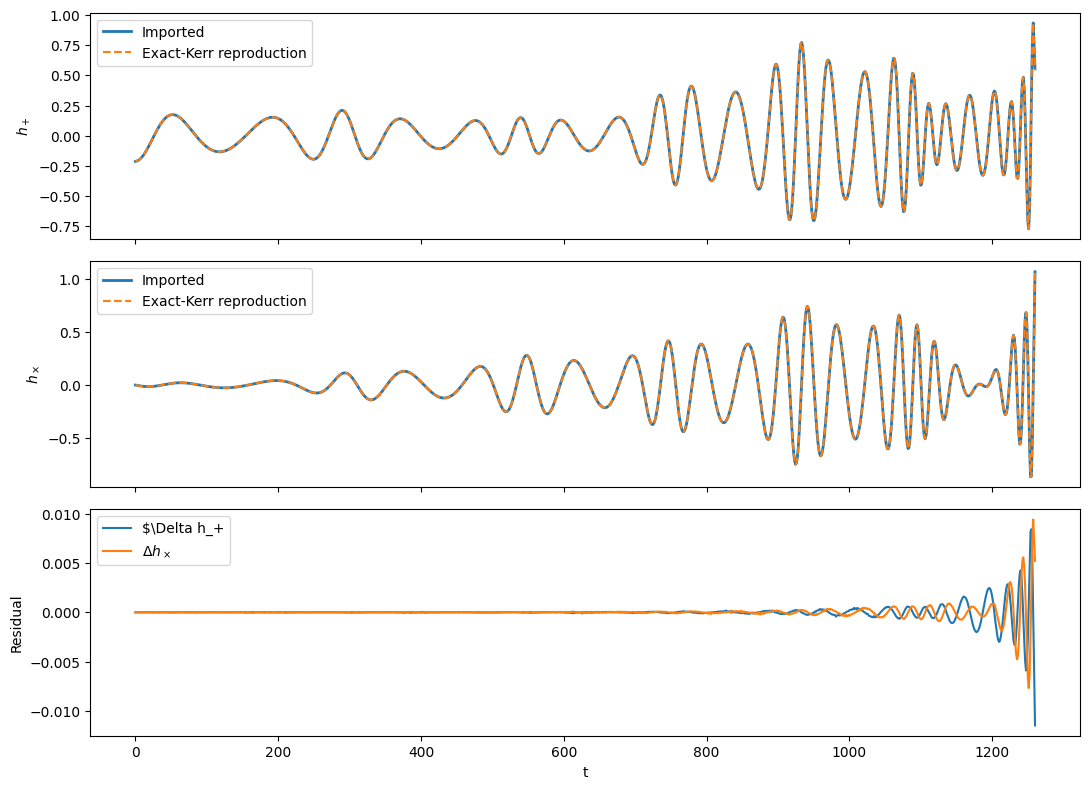

In [33]:
fig, ax = plt.subplots(3, 1, figsize = (11,8), sharex=True)

ax[0].plot(t_test, h_plus_reference, label = "Imported", linewidth=2)
ax[0].plot(t_test, h_plus_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[0].set_ylabel(r"$h_+$")
ax[0].legend()

ax[1].plot(t_test, h_cross_reference, label = "Imported", linewidth = 2)
ax[1].plot(t_test, h_cross_gate.detach(), "--", label = "Exact-Kerr reproduction")
ax[1].set_ylabel(r"$h_\times$")
ax[1].legend()

ax[2].plot(t_test, (h_plus_gate - h_plus_reference).detach(), label = r"$\Delta h_+")
ax[2].plot(t_test, (h_cross_gate-h_cross_reference).detach(), label = r"$\Delta h_\times$")
ax[2].set_xlabel("t")
ax[2].set_ylabel("Residual")
ax[2].legend()

plt.tight_layout()

# Ricci Loss Term

## Ricci Loss Term Components

In [34]:
def christ_awful(metric, x):
  partial_g = torch.func.jacfwd(metric)(x)
  ginv = torch.linalg.inv(metric(x))
  term1 = torch.einsum("ms, sab->mab", ginv, partial_g)
  term2 = torch.einsum("ms, sba->mab", ginv, partial_g)
  term3 = torch.einsum("ms, abs->mab", ginv, partial_g)
  christoffel = 0.5 * (term1 + term2 - term3)
  return christoffel

In [35]:
def Riemann(metric, x):
  dGamma = torch.func.jacfwd(christ_awful, argnums=1)(metric, x)
  term1 = torch.einsum("abvu->abuv", dGamma)
  term2 = torch.einsum("abuv->abuv", dGamma)
  term3 = torch.einsum("aup,pbv->abuv", christ_awful(metric, x), christ_awful(metric, x))
  term4 = torch.einsum("avp,pbu->abuv", christ_awful(metric, x), christ_awful(metric, x))
  Riemann = term1 - term2 + term3 - term4
  return Riemann

In [36]:
def Ricci(metric, x):
  ricci = torch.einsum("abav->bv", Riemann(metric, x))
  return ricci

## Gate: Test on Exact Schwarzschild & Kerr Metrics

In [37]:
def Schwarzschild(x, M=1):
  zero = torch.tensor(0.)
  r = x[1]
  θ = x[2]
  g_tt = -(1-2*M/r)
  g_rr = (1-2*M/r)**(-1)
  g_θθ = r**2
  g_ϕϕ = r**2 * (torch.sin(θ))**2
  row1 = torch.stack([g_tt, zero, zero, zero])
  row2 = torch.stack([zero, g_rr, zero, zero])
  row3 = torch.stack([zero, zero, g_θθ, zero])
  row4 = torch.stack([zero, zero, zero, g_ϕϕ])
  schild = torch.stack([row1, row2, row3, row4])
  return schild

In [38]:
x = torch.tensor([0.0, 10.0, math.pi/2, 0.0])
input_spin = torch.tensor(0.9, dtype = x.dtype)
kerr_gate = lambda x: Kerr(x, a=input_spin)
schwarzschild_gate = lambda x: Schwarzschild(x)
print("Kerr Gate:", Ricci(kerr_gate, x))
print("\nSchwarzschild Gate:", Ricci(schwarzschild_gate, x))

Kerr Gate: tensor([[ 3.4925e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09, -3.3654e-16,  0.0000e+00],
        [ 0.0000e+00,  1.1484e-15,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.7881e-07]])

Schwarzschild Gate: tensor([[-1.1642e-10,  0.0000e+00,  0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  2.3283e-09,  8.8818e-16,  0.0000e+00],
        [ 0.0000e+00,  8.8818e-16,  1.4901e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.4901e-08]])


# Frequency Loss Term

## $L(\tilde{h}_{pred}, \tilde{h}_{true})$

In [39]:
def SpectralLoss(h_true, h_pred):
    """
    Measures mean relative squared FFT-magnitude error.
    Ensures the network hears the 'ISCO Cliff' and 'Inspiral Slope' equally [1].
    """
    N = h_true.size(0)
    # Ensure window is on the same device as the data
    hann_window = torch.hann_window(N, periodic=True).to(h_true.device)

    # Apply window to prevent edge-effect frequency leakage
    h_true_fft = torch.fft.fft(hann_window * h_true)
    h_pred_fft = torch.fft.fft(hann_window * h_pred)

    # Use log-scale to handle the orders of magnitude in the FrequencyGW profile [1]
    h_true_mag = torch.abs(h_true_fft)
    h_pred_mag = torch.abs(h_pred_fft)

    eps = 1e-4 * h_true_mag.pow(2).mean()

    num = (h_true_mag - h_pred_mag).pow(2)
    spec_loss = num / (h_true_mag.pow(2) + eps)
    spec_loss_avg = spec_loss.mean()

    spec_loss = spec_loss_avg
    return spec_loss

## Gate: $L_{\omega}(h_{true},h_{true})=0$

In [40]:
# Gate: SpectralLoss(h_true, h_true) should be 0
test_h = torch.complex(h_plus_true_obs1, h_cross_true_obs1)
gate_val = SpectralLoss(test_h, test_h)
print(gate_val)

tensor(0.)


## Gate: Kerr Circular, Equatorial Frequency $\Omega=\frac{M^{1/2}}{r^{3/2}+aM^{1/2}}$

In [41]:
def AnalyticFrequencyGate(r_val=10.0, a_spin=0.9, M=1.0):
    """
    SpaceX-style pre-flight check: Tests the SpectralLoss against the
    theoretical Kerr frequency Ω = sqrt(M) / (r^1.5 + a*sqrt(M)).
    """
    # 1. Calculate analytic GW frequency (ω = 2 * Ω) [1]
    omega_orbit = math.sqrt(M) / (r_val**1.5 + a_spin * math.sqrt(M))
    omega_gw = 2 * omega_orbit

    # 2. Create synthetic pure-tone signal (exp(i * omega * t))
    # Using the same time array as your training window (e.g., 1000 samples)
    t_gate = t.detach().clone()
    h_analytic = torch.complex(torch.cos(omega_gw * t_gate),
                               torch.sin(omega_gw * t_gate))

    # 3. Test 1: Self-consistency (Perfect match should be ~0)
    loss_self = SpectralLoss(h_analytic, h_analytic)

    # 4. Test 2: Frequency Sensitivity (Shift frequency by 1% to test 'ears')
    h_shifted = torch.complex(torch.cos(1.01 * omega_gw * t_gate),
                              torch.sin(1.01 * omega_gw * t_gate))
    loss_shifted = SpectralLoss(h_analytic, h_shifted)

    print(f"--- Analytic Frequency Gate (r={r_val}, a={a_spin}) ---")
    print(f"Theoretical ω_GW: {omega_gw:.6f}")
    print(f"Gate Self-Loss:   {loss_self.item():.2e} (Success if ~0)")
    print(f"Gate Shift-Loss:  {loss_shifted.item():.2e} (Success if > 0)")

    return loss_self, loss_shifted

# Run before launching the Golden Run
AnalyticFrequencyGate(r_val=10.0, a_spin=a_true)

--- Analytic Frequency Gate (r=10.0, a=0.9) ---
Theoretical ω_GW: 0.061495
Gate Self-Loss:   0.00e+00 (Success if ~0)
Gate Shift-Loss:  8.16e-04 (Success if > 0)


(tensor(0.), tensor(0.0008))

## Frequency Loss Plot

In [42]:
def plotSpectralDiagnostic(h_true, h_pred, dt=1.0):
    """
    Visualizes the spectral 'DNA' match between True and Predicted signals.
    Mirrors the 'FrequencyGW' log-log profile [120, user history].
    """
    N = h_true.size(0)
    hann_window = torch.hann_window(N, periodic=True).to(h_true.device)

    # Compute FFTs of windowed signals [user history]
    f_true = torch.fft.fft(hann_window * h_true)
    f_pred = torch.fft.fft(hann_window * h_pred)

    freqs = torch.fft.fftfreq(N, d=dt, device=h_true.device)
    positive = freqs > 0

    # Frequency axis in Hz (assuming dt from your create_gravityWave function) [2]
    freqs = freqs[positive].detach().cpu()


    # Magnitudes [1]
    mag_true = torch.abs(f_true[positive]).detach().cpu()
    mag_pred = torch.abs(f_pred[positive]).detach().cpu()

    plt.figure(figsize=(10, 6))
    plt.loglog(freqs, mag_true, 'r-', label='True (Analytical)', linewidth=2)
    plt.loglog(freqs, mag_pred, 'g--', label='Predicted (Network)', linewidth=2)

    plt.title("Spectral Magnitude Profile: $|\tilde{h}(f)|$ vs $f$")
    plt.xlabel("Frequency $f$ [Hz]")
    plt.ylabel("Magnitude $|\tilde{h}(f)|$")
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.legend()
    plt.show()

# Boundary Condition Loss Term

## 4 Tricks: Square, Normalize, Exponentiate, and Weight

In [43]:
import torch

def resid(metric, x):
    g_rr = metric(x)[1,1]
    g_rr_inv = 1/g_rr
    return g_rr_inv

def boundaryConditionLoss(metric):
  M = 1
  zero = torch.tensor(0.)
  r_vals = torch.linspace(1*M, 2.01*M, 40)
  θ_vals = torch.linspace(0, math.pi/2, 2)
  tau = 1e-4

  roots = []
  root_residuals = [] # g^{rr}(r_H, θ)^2 -- penalizes "no real zero here"
  sign_penalties = []


  for θ in θ_vals:
    badness_vals = []
    for r in r_vals:
      x = torch.stack([zero, r, θ, zero])
      badness = resid(metric, x)**2 # square it
      badness_vals.append(badness) # add it to the array

    weights = torch.softmax(-torch.stack(badness_vals)/tau, dim=0)
    weighted_average = (weights * r_vals).sum()
    roots.append(weighted_average)

    x_root = torch.stack([zero, weighted_average, θ, zero])
    root_residuals.append(resid(metric, x_root)**2)

    x_lo = torch.stack([zero, r_vals[0], θ, zero])
    x_hi = torch.stack([zero, r_vals[-1], θ, zero])
    sign_penalties.append(F.relu(resid(metric, x_lo) * resid(metric, x_hi))) # >0 only if same-sign (no crossing)

  location_consistency = torch.var(torch.stack(roots))
  zero_crossing_penalty = torch.stack(root_residuals).mean()
  sign_change_penalty = torch.stack(sign_penalties).mean()

  L2_norm_BC_loss = location_consistency + zero_crossing_penalty + sign_change_penalty

  return L2_norm_BC_loss, roots

## Gate: Kerr $a=0, r_H=1.43M$

In [44]:
metric_fn = lambda x: Kerr(x, a = 0.9)
boundaryConditionLoss(metric_fn)

(tensor(1.2509e-07), [tensor(1.4356), tensor(1.4361)])

## Gate: Schwarzschild $a=0, r_H=2M$

In [45]:
metric_fn = lambda x: Kerr(x, a = 0)
boundaryConditionLoss(metric_fn)

(tensor(1.4365e-07), [tensor(1.9992), tensor(1.9992)])

# Loss Function

Things to test:
- Exponential ricci grid sampling (i.e., `r_grid = 1 +. 10^([-3, 3, 10])`) so that near-Horizon is sampled more strongly than far-away
- A very good training log required to log / print out the weights of each loss term as they change, the predicted metric as it evolves during training, etc.

In [46]:
π = math.pi

P_WAVEFORM = 1.0
P_RICCI = 0.5
P_FREQUENCY = 0.1
P_BC = 0.1

def loss(network):
  # --------- RICCI LOSS ---------------
  r_grid = torch.logspace(math.log10(2.0), math.log10(20.0), steps=10)
  θ_grid = torch.linspace(π/20, π/2, 2)

  def g(x):
    return metric_from_network(network, x[1], x[2])

  ricci_sum = torch.zeros(())
  ricci_count = 0

  for r in r_grid:
    for θ in θ_grid:
      zero = torch.tensor(0.)
      x = torch.stack([zero, r, θ, zero])
      ricci_sum += Ricci(g, x).pow(2).sum()
      ricci_count += 1

  ricciLoss = ricci_sum / ricci_count

  # --------- WAVEFORM LOSS ---------------
  waveformLoss, pred_h_real, pred_h_imag = waveform_loss(network)
  h_pred_complex = torch.complex(pred_h_real[0], pred_h_imag[0])
  h_true_complex = torch.complex(h_plus_true[0], h_cross_true[0])

  # --------- BOUNDARY LOSS ---------------
  boundaryCondition_Loss, roots = boundaryConditionLoss(g)

  # --------- FREQUENCY LOSS ---------------
  freq_Loss = SpectralLoss(h_true_complex, h_pred_complex)

  # --------- TOTAL LOSS ---------------
  total_loss = (P_WAVEFORM * waveformLoss
              + P_RICCI * ricciLoss
              + P_FREQUENCY * freq_Loss
              + P_BC * boundaryCondition_Loss)

  return (total_loss, waveformLoss,
          ricciLoss, freq_Loss,
          boundaryCondition_Loss.detach(), roots)

# Checkpoints

In [47]:
import os
from google.colab import drive
drive.mount("/content/drive")

CHECKPOINT_PATH = "/content/drive/MyDrive/sonar_v11_single.pt"

def save_checkpoint(stride_idx, epoch, n, loss_history):
  torch.save({
      "net_state": net.state_dict(),
      "stride_idx": stride_idx,
      "epoch": epoch,
      "n": n,
      "loss_history": loss_history,
  }, CHECKPOINT_PATH)

def load_checkpoint():
  if not os.path.exists(CHECKPOINT_PATH):
    return None
  return torch.load(CHECKPOINT_PATH)

Mounted at /content/drive


# Diagnostics Log

In [48]:
from prettytable import PrettyTable
import time

def rel_L2_error(pred, true, eps = 1e-12):
  return 100 * torch.sqrt(
                          torch.sum((pred - true) ** 2) / (torch.sum((true) ** 2) + eps)
                         )

# -------- Psuedo-code structure --------
# for each radius:
  # evaluate predicted metric at each \theta on a grid [π/20, π/4, π/3, π/2]
  # stack the \theta-profile of the metrics into a tensor of shape [n_theta, 4, 4]
  # compute L2 error for each metric component (i.e., g_tt, g_rr, etc.) across all theta values via L2(g_pred[:, \mu, \nu], g_true[:, \mu, \nu])
  # add that relative angular-profile error at a given radius for a given metric component as a row to the diagnostics table

def log_diagnostics(
    network, total_loss,
    w, r, f, b, roots, n,
    elapsed_time
  ):

  r_grid = [2, 3, 4, 5, 6, 12, 20] # Use these explicit r values
  θ_grid = [π/20, π/4, π/3, π/2] # Use these explicit θ values

  gtt_error_vals = []
  grr_error_vals = []
  gθθ_error_vals = []
  gϕϕ_error_vals = []
  gtϕ_error_vals = []
  ricci_error_vals = []

  param = next(network.parameters())

  for r_val in r_grid:
    pred_vec = []
    true_vec = []
    ricci_at_radius = []

    for θ in θ_grid:
      r_t = torch.tensor(r_val, dtype = param.dtype, device = param.device)
      θ_t = torch.tensor(θ, dtype = param.dtype, device = param.device)

      pred_g = metric_from_network(network, r_t, θ_t)
      true_g = g_Kerr(r_t, θ_t)

      pred_vec.append(pred_g)
      true_vec.append(true_g)

    pred_vec = torch.stack(pred_vec)
    true_vec = torch.stack(true_vec)

    gtt_error_vals.append(rel_L2_error(pred_vec[:, 0, 0], true_vec[:, 0, 0]).detach().item())
    grr_error_vals.append(rel_L2_error(pred_vec[:, 1, 1], true_vec[:, 1, 1]).detach().item())
    gθθ_error_vals.append(rel_L2_error(pred_vec[:, 2, 2], true_vec[:, 2, 2]).detach().item())
    gϕϕ_error_vals.append(rel_L2_error(pred_vec[:, 3, 3], true_vec[:, 3, 3]).detach().item())
    gtϕ_error_vals.append(rel_L2_error(pred_vec[:, 0, 3], true_vec[:, 0, 3]).detach().item())

  metric_table = PrettyTable()
  metric_table.title = "Metric Relative L2 Error Across θ (%)"
  metric_table.field_names = [
      "Component",
      *[f"r={r_val}" for r_val in r_grid]
  ]

  metric_table.add_row(["g_tt", *gtt_error_vals])
  metric_table.add_row(["g_rr", *grr_error_vals])
  metric_table.add_row(["g_θθ", *gθθ_error_vals])
  metric_table.add_row(["g_ϕϕ", *gϕϕ_error_vals])
  metric_table.add_row(["g_tϕ", *gtϕ_error_vals])
  metric_table.float_format = ".2"

  total_value = total_loss.detach().item()
  w_relL2 = 100 * torch.sqrt(w.clamp_min(0)).item()
  r_H = torch.stack(roots).mean().detach().item()

  w_Loss = P_WAVEFORM * w.item()
  r_LOSS = P_RICCI * r.item()
  f_LOSS = P_FREQUENCY * f.item()
  b_LOSS = P_BC * b.item()

  print(
      f"iter={n:4d} | "
      f"time={elapsed_time:7.1f}s | "
      f"total={total_value:.3e} | "
      f"W_err={w_relL2:5.1f}% | "
      f"r_H={r_H:.4f} | "
      f"contrib: W={w_Loss:.2e}, F={f_LOSS:.2e},"
      f"R={r_LOSS:.2e}, BC={b_LOSS:.2e}"
  )

  print(metric_table)

  return metric_table

# Training

In [49]:
import _optimize as ssbroyden_patch
import scipy.optimize._optimize as scipy_internal
import scipy.optimize._minimize as scipy_dispatch

scipy_internal._minimize_bfgs = ssbroyden_patch._minimize_bfgs
scipy_dispatch._minimize_bfgs = ssbroyden_patch._minimize_bfgs

from scipy.optimize import minimize as minimize_ssbroyden

In [50]:
def report_gradient_geometry(network, waveformLoss, ricciLoss):
  params = list(network.parameters())

  grad_W = torch.autograd.grad(
      P_WAVEFORM * waveformLoss,
      params,
      retain_graph=True
  )
  grad_R = torch.autograd.grad(
      P_RICCI * ricciLoss,
      params,
      retain_graph=True
  )

  grad_W = torch.cat([g.flatten() for g in grad_W])
  grad_R = torch.cat([g.flatten() for g in grad_R])

  G_W = torch.linalg.vector_norm(grad_W)
  G_R = torch.linalg.vector_norm(grad_R)
  cosine = torch.dot(grad_W, grad_R) / (G_W * G_R + 1e-30)
  ratio = G_R / (G_W + 1e-30)

  print(
      f"gradient geometry: |P_W∇L_W|={G_W.item():.3e} | "
      f"|P_R∇L_R|={G_R.item():.3e} | "
      f"R/W={ratio.item():.3e} | cos(W,R)={cosine.item():+.3f}"
  )


In [51]:
loss_history = []
waveform_loss_history = []
ricci_loss_history = []
frequency_loss_history = []
boundaryCondition_loss_history = []

n = 0
start_stage_idx = 0
start_epoch = 0

ckpt = load_checkpoint()

if ckpt is not None:
  # Preserve float64 BFGS checkpoints instead of silently casting through float32.
  checkpoint_dtype = next(iter(ckpt["net_state"].values())).dtype
  if checkpoint_dtype == torch.float64:
    net = net.to(dtype=torch.float64)
  net.load_state_dict(ckpt["net_state"])
  n = ckpt["n"]
  loss_history = ckpt["loss_history"]

  start_stage_idx = ckpt["stride_idx"]
  start_epoch = ckpt["epoch"] + 1
  print(f"Resumed from stride {start_stage_idx}, epoch {start_epoch}, n={n}")

t_full = t.detach().clone()
hp_full = [h_plus_true_obs1]
hc_full = [h_cross_true_obs1]

# Short Adam warm-up only. V8's last healthy checkpoint was [0:100].
schedule = [
    (25, 45),
    (50, 40),
    (100, 35),
]

optimizer = torch.optim.Adam(net.parameters(), lr = 1e-2)
start_time = time.time()

for stage_idx, (window, epochs) in enumerate(schedule):
  if stage_idx < start_stage_idx:
    continue

  lr_stage = 1e-2 if window <= 300 else 2e-3 * (400/window)
  optimizer = torch.optim.Adam(net.parameters(), lr = lr_stage)

  t_test = t_full[:window]
  h_plus_true = [hp[:window] for hp in hp_full]
  h_cross_true = [hc[:window] for hc in hc_full]
  epoch0 = start_epoch if stage_idx == start_stage_idx else 0

  print(f"\\nAdam stage {stage_idx + 1}/{len(schedule)}: samples [0:{window}], {epochs} iterations")

  for epoch in range(epoch0, epochs):
    optimizer.zero_grad()

    total_loss, w, r, f, b, roots = loss(net)

    if (n + 1) % 10 == 0:
      report_gradient_geometry(net, w, r)

    elapsed_time = time.time() - start_time
    log_diagnostics(net, total_loss,
                    w, r, f, b, roots,
                    n, elapsed_time)

    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        net.parameters(),
        1.0,
        error_if_nonfinite=True
    )

    optimizer.step()

    loss_history.append(total_loss.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    n += 1

    if n % 10 == 0:
      save_checkpoint(stage_idx, epoch, n, loss_history)

  save_checkpoint(stage_idx, epochs - 1, n, loss_history)

  print(f"Adam complete: {n} total iterations")

\nAdam stage 1/3: samples [0:25], 45 iterations
iter=   0 | time=    2.0s | total=2.221e+00 | W_err=139.0% | r_H=1.5050 | contrib: W=1.93e+00, F=4.35e-02,R=6.67e-03, BC=2.40e-01
+--------------------------------------------------------------------------+
|                  Metric Relative L2 Error Across θ (%)                   |
+-----------+--------+--------+--------+--------+--------+--------+--------+
| Component |  r=2   |  r=3   |  r=4   |  r=5   |  r=6   |  r=12  |  r=20  |
+-----------+--------+--------+--------+--------+--------+--------+--------+
|    g_tt   | 865.22 | 163.37 | 87.24  | 59.26  | 44.80  | 18.10  | 10.07  |
|    g_rr   | 81.41  | 59.32  | 46.21  | 37.74  | 31.86  | 16.40  |  9.95  |
|    g_θθ   | 12.08  |  5.65  |  3.23  |  2.09  |  1.46  |  0.37  |  0.13  |
|    g_ϕϕ   | 28.96  | 13.25  |  7.25  |  4.50  |  3.04  |  0.69  |  0.24  |
|    g_tϕ   | 124.11 | 122.92 | 122.32 | 121.97 | 121.73 | 121.13 | 120.90 |
+-----------+--------+--------+--------+--------+---

## Float64 BFGS handoff


In [52]:
def switch_to_float64_for_bfgs():
  global net, t_full, hp_full, hc_full
  global t_test, h_plus_true, h_cross_true

  # New tensors created inside ODE/Ricci/BC code now default to float64.
  torch.set_default_dtype(torch.float64)

  net = net.to(dtype=torch.float64)
  t_full = t_full.to(dtype=torch.float64)
  hp_full = [hp.to(dtype=torch.float64) for hp in hp_full]
  hc_full = [hc.to(dtype=torch.float64) for hc in hc_full]

  # Rebuild handoff window explicitly; robust when resuming a checkpoint.
  handoff_window = schedule[-1][0]
  t_test = t_full[:handoff_window]
  h_plus_true = [hp[:handoff_window] for hp in hp_full]
  h_cross_true = [hc[:handoff_window] for hc in hc_full]

  assert next(net.parameters()).dtype == torch.float64
  assert t_full.dtype == torch.float64
  assert all(h.dtype == torch.float64 for h in hp_full + hc_full)

  print("BFGS precision:", next(net.parameters()).dtype)


switch_to_float64_for_bfgs()

# One diagnostic at the Adam→BFGS handoff.
handoff_total, handoff_w, handoff_r, handoff_f, handoff_b, handoff_roots = loss(net)
report_gradient_geometry(net, handoff_w, handoff_r)
del handoff_total, handoff_w, handoff_r, handoff_f, handoff_b, handoff_roots


BFGS precision: torch.float64
gradient geometry: |P_W∇L_W|=9.066e-02 | |P_R∇L_R|=7.007e-02 | R/W=7.728e-01 | cos(W,R)=+0.746


In [53]:
def as_float(x):
  return float(x.detach().cpu()) if torch.is_tensor(x) else float(x)

In [54]:
def loss_and_gradient(x, reject_bad=True):
  ref = next(net.parameters())
  x_t = torch.as_tensor(x, dtype=ref.dtype, device=ref.device)

  with torch.no_grad():
    torch.nn.utils.vector_to_parameters(x_t, net.parameters())

  net.zero_grad(set_to_none=True)

  try:
    L, w, r, f, b, roots = loss(net)

    if not torch.isfinite(L):
      raise FloatingPointError

    L.backward()
    grad = torch.nn.utils.parameters_to_vector(
        [p.grad for p in net.parameters()]
    )

    if not torch.isfinite(grad).all():
      raise FloatingPointError

    loss_history.append(L.item())
    waveform_loss_history.append(P_WAVEFORM*w.item())
    ricci_loss_history.append(P_RICCI*r.item())
    frequency_loss_history.append(P_FREQUENCY*f.item())
    boundaryCondition_loss_history.append(P_BC*b.item())

    return(
        float(L.detach().cpu()),
        grad.detach().cpu().numpy().astype(np.float64),
    )

  except (RuntimeError, FloatingPointError) as e:
    if not reject_bad:
        raise
    return 1e30, np.zeros_like(x, dtype=np.float64)

def ssbroyden_callback(intermediate_result):
  with torch.no_grad():
    ref = next(net.parameters())
    accepted_x = torch.as_tensor(
        intermediate_result.x,
        dtype=ref.dtype,
        device=ref.device
    )
    torch.nn.utils.vector_to_parameters(
        accepted_x,
        net.parameters()
    )

  save_checkpoint(
        len(schedule) - 1,
        schedule[-1][1] - 1,
        n,
        loss_history
  )

  elapsed = time.time() - bfgs_start_time

  print(
      "BFGS Loss:", intermediate_result.fun,
      "evaluations:", getattr(intermediate_result, "nfev", "?"),
      "elapsed:", elapsed
  )

x0 = (
    torch.nn.utils.parameters_to_vector(net.parameters())
    .detach().cpu().numpy().astype(np.float64)
)

t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

In [55]:
def run_bfgs_stage(window, maxiter):
  global t_test, h_plus_true, h_cross_true

  t_test = t_full[:window]
  h_plus_true = [hp[:window] for hp in hp_full]
  h_cross_true = [hc[:window] for hc in hc_full]

  x0 = (
      torch.nn.utils.parameters_to_vector(net.parameters())
      .detach()
      .cpu()
      .numpy()
      .astype(np.float64)
  )

  # Strict handoff gate
  gate_loss, gate_grad = loss_and_gradient(
      x0,
      reject_bad=False
  )

  grad_norm = np.linalg.norm(gate_grad)

  print(
      f"[0:{window}] gate: "
      f"loss={gate_loss:.3e}, "
      f"|grad|={grad_norm:.3e}, "
      f"finite_grad={np.isfinite(gate_grad).all()}"
  )

  assert (
      np.isfinite(gate_loss)
      and gate_loss < 1e29
      and np.isfinite(gate_grad).all()
      and grad_norm > 1e-12
  ), f"[0:{window}] invalid BFGS handoff — use a smaller window"

  result = minimize_ssbroyden(
      loss_and_gradient,
      x0,
      jac=True,
      method="BFGS",
      callback=ssbroyden_callback,
      options={
          "maxiter": maxiter,
          "gtol": 1e-4,
          "method_bfgs": "SSBroyden2",
          "initial_scale": False,
          "disp": True,
      },
  )

  with torch.no_grad():
    ref = next(net.parameters())
    final_x = torch.as_tensor(
        result.x,
        dtype=ref.dtype,
        device=ref.device,
    )
    torch.nn.utils.vector_to_parameters(
        final_x,
        net.parameters(),
    )

  print(
      f"[0:{window}] done: "
      f"loss={result.fun:.3e}, "
      f"iters={result.nit}, "
      f"evals={result.nfev}\n"
  )

  return result

adam_end = len(loss_history)
bfgs_start_time = time.time()
result = run_bfgs_stage(200, 20)
result = run_bfgs_stage(400, 20)
result = run_bfgs_stage(600, 25)
result = run_bfgs_stage(800, 30)
result = run_bfgs_stage(1000, 60)

bfgs_elapsed = time.time() - bfgs_start_time
total_elapsed = time.time() - start_time

print("\nBFGS Summary")
print("success:", result.success)
print("status:", result.status)
print("message:", result.message)
print("iterations:", result.nit)
print("function evaluations", result.nfev)
print("gradient evaluations", result.njev)
print("final loss:", result.fun)
print("BFGS elapsed:", bfgs_elapsed / 60, "minutes")
print("total Adam+BFGS elapsed:", total_elapsed / 60, "minutes")

if hasattr(result, "jac"):
  print("final ||gradient||:", np.linalg.norm(result.jac, ord=np.inf))
if "precision loss" in str(result.message).lower():
  print(
      "Precision loss remains in float64. "
      "Check ODE tolerances and objective smoothness before raising maxiter."
  )

[0:200] gate: loss=6.043e-02, |grad|=1.712e+01, finite_grad=True
BFGS Loss: 0.010127199377683157 evaluations: 5 elapsed: 46.65276479721069
BFGS Loss: 0.009984744279078583 evaluations: 7 elapsed: 62.519232749938965
BFGS Loss: 0.009758686842115205 evaluations: 8 elapsed: 70.26804637908936
BFGS Loss: 0.009699100680685408 evaluations: 9 elapsed: 78.52544212341309
BFGS Loss: 0.009584983378746189 evaluations: 10 elapsed: 85.77255463600159
BFGS Loss: 0.0085495984558872 evaluations: 12 elapsed: 101.17751479148865
BFGS Loss: 0.0071143018029811 evaluations: 13 elapsed: 109.5920832157135
BFGS Loss: 0.006236393768137329 evaluations: 15 elapsed: 125.48426699638367
BFGS Loss: 0.005676727999924792 evaluations: 16 elapsed: 132.86196208000183
BFGS Loss: 0.005420749235590969 evaluations: 18 elapsed: 149.35792112350464
BFGS Loss: 0.0051064441052732544 evaluations: 19 elapsed: 157.05996704101562
BFGS Loss: 0.00497447449053296 evaluations: 20 elapsed: 165.31535410881042
BFGS Loss: 0.0047657034503185295 eva

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


[0:400] gate: loss=3.930e-02, |grad|=2.293e+01, finite_grad=True
BFGS Loss: 0.019897190838494068 evaluations: 5 elapsed: 342.14493346214294
BFGS Loss: 0.016027890764117137 evaluations: 7 elapsed: 369.6978976726532
BFGS Loss: 0.009833371023536949 evaluations: 8 elapsed: 383.4786956310272
BFGS Loss: 0.0060079345375531135 evaluations: 9 elapsed: 396.8744168281555
BFGS Loss: 0.005876343300884377 evaluations: 11 elapsed: 423.15776658058167
BFGS Loss: 0.005808544069603681 evaluations: 12 elapsed: 436.25266194343567
BFGS Loss: 0.00571562764391892 evaluations: 13 elapsed: 449.71307492256165
BFGS Loss: 0.005554039843278419 evaluations: 14 elapsed: 463.1846580505371
BFGS Loss: 0.005275097258577664 evaluations: 15 elapsed: 477.14088201522827
BFGS Loss: 0.00493288902793958 evaluations: 16 elapsed: 490.92064213752747
BFGS Loss: 0.004425909289098264 evaluations: 17 elapsed: 504.4726417064667
BFGS Loss: 0.004180716342950946 evaluations: 19 elapsed: 531.614305973053
BFGS Loss: 0.004059089589262192 eva

/usr/local/lib/python3.12/dist-packages/scipy/optimize/_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


# Results

In [56]:
t_test = t_full
h_plus_true = hp_full
h_cross_true = hc_full

final_total, final_w, final_r, final_f, final_b, final_roots = loss(net)

report_gradient_geometry(net, final_w, final_r)

log_diagnostics(
    net,
    final_total,
    final_w,
    final_r,
    final_f,
    final_b,
    final_roots,
    n + result.nit,
    time.time() - start_time
)

gradient geometry: |P_W∇L_W|=6.662e+01 | |P_R∇L_R|=8.054e-03 | R/W=1.209e-04 | cos(W,R)=+0.673
iter= 120 | time= 3598.3s | total=1.360e-02 | W_err= 11.4% | r_H=1.3657 | contrib: W=1.29e-02, F=4.59e-04,R=1.98e-04, BC=4.37e-06
+---------------------------------------------------------------+
|             Metric Relative L2 Error Across θ (%)             |
+-----------+-------+------+------+------+------+-------+-------+
| Component |  r=2  | r=3  | r=4  | r=5  | r=6  |  r=12 |  r=20 |
+-----------+-------+------+------+------+------+-------+-------+
|    g_tt   | 48.83 | 2.13 | 0.49 | 0.44 | 0.37 |  0.10 |  0.03 |
|    g_rr   | 15.23 | 5.80 | 3.30 | 2.21 | 1.64 |  0.61 |  0.34 |
|    g_θθ   |  6.10 | 3.53 | 2.24 | 1.54 | 1.12 |  0.31 |  0.12 |
|    g_ϕϕ   |  9.65 | 2.01 | 0.27 | 0.19 | 0.30 |  0.18 |  0.08 |
|    g_tϕ   | 23.62 | 8.98 | 1.59 | 4.34 | 7.71 | 16.71 | 20.49 |
+-----------+-------+------+------+------+------+-------+-------+


Component,r=2,r=3,r=4,r=5,r=6,r=12,r=20
g_tt,48.83,2.13,0.49,0.44,0.37,0.10,0.03
g_rr,15.23,5.80,3.30,2.21,1.64,0.61,0.34
g_θθ,6.10,3.53,2.24,1.54,1.12,0.31,0.12
g_ϕϕ,9.65,2.01,0.27,0.19,0.30,0.18,0.08
g_tϕ,23.62,8.98,1.59,4.34,7.71,16.71,20.49


## One-dimensional $g_{t\phi}$ sensitivity scan


In [57]:
def alpha_scan(alphas=(0.0, 0.25, 0.5, 0.75, 1.0)):
  global GTPHI_ALPHA, t_test, h_plus_true, h_cross_true

  old_alpha = GTPHI_ALPHA
  old_t_test = t_test
  old_h_plus = h_plus_true
  old_h_cross = h_cross_true

  t_test = t_full
  h_plus_true = hp_full
  h_cross_true = hc_full
  rows = []

  try:
    for alpha in alphas:
      GTPHI_ALPHA = float(alpha)
      total, w, r, f, b, roots = loss(net)
      rows.append({
          "alpha": float(alpha),
          "waveform": w.detach().item(),
          "ricci": r.detach().item(),
          "total": total.detach().item(),
      })
      del total, w, r, f, b, roots
  finally:
    GTPHI_ALPHA = old_alpha
    t_test = old_t_test
    h_plus_true = old_h_plus
    h_cross_true = old_h_cross

  table = PrettyTable()
  table.field_names = ["alpha", "L_W", "L_R", "P_W L_W", "P_R L_R", "L_total"]
  for row in rows:
    table.add_row([
        f"{row['alpha']:.2f}",
        f"{row['waveform']:.3e}",
        f"{row['ricci']:.3e}",
        f"{P_WAVEFORM * row['waveform']:.3e}",
        f"{P_RICCI * row['ricci']:.3e}",
        f"{row['total']:.3e}",
    ])

  print(table)
  return rows


alpha_scan_results = alpha_scan()


+-------+-----------+-----------+-----------+-----------+-----------+
| alpha |    L_W    |    L_R    |  P_W L_W  |  P_R L_R  |  L_total  |
+-------+-----------+-----------+-----------+-----------+-----------+
|  0.00 | 1.293e-02 | 3.951e-04 | 1.293e-02 | 1.976e-04 | 1.360e-02 |
|  0.25 | 5.370e-01 | 1.115e-02 | 5.370e-01 | 5.577e-03 | 5.452e-01 |
|  0.50 | 1.655e+00 | 3.625e-02 | 1.655e+00 | 1.812e-02 | 1.677e+00 |
|  0.75 | 2.467e+00 | 6.856e-02 | 2.467e+00 | 3.428e-02 | 2.506e+00 |
|  1.00 | 2.743e+00 | 1.038e-01 | 2.743e+00 | 5.189e-02 | 2.801e+00 |
+-------+-----------+-----------+-----------+-----------+-----------+


In [58]:
x0 = torch.nn.utils.parameters_to_vector(net.parameters()).detach().clone()
print(x0)

tensor([-0.1597,  0.3086, -0.7696, -0.4913,  0.3661,  0.4827,  0.4299,  0.2846,
         0.0284, -0.0122, -0.5386, -0.2191, -2.2070, -0.3849, -0.7943,  0.5569,
         0.7633,  1.3332, -0.1724, -0.5993,  0.1750,  0.4386,  0.0053,  0.7262,
         0.0885,  0.6964, -0.3050, -0.6077,  0.1653,  0.2593, -1.4404,  0.5118,
        -0.6878, -0.4533,  0.3372,  0.3420, -0.5233, -0.2882,  0.3531, -0.4663,
         0.3529, -0.1350, -0.0091, -0.4575,  0.1095,  0.4241,  0.0127,  0.5732,
        -0.0097,  0.6299, -0.2582, -0.1561,  0.5948,  0.4718, -0.3089, -0.0126,
        -0.4066, -0.9750,  0.0243,  0.0685,  0.1603, -0.6524, -0.3012, -1.1406,
         0.7163, -0.6144,  0.1208,  0.3900, -0.2963])


In [59]:
print(dict(net.named_parameters()))

{'fc1.weight': Parameter containing:
tensor([[-0.1597,  0.3086],
        [-0.7696, -0.4913],
        [ 0.3661,  0.4827],
        [ 0.4299,  0.2846],
        [ 0.0284, -0.0122],
        [-0.5386, -0.2191],
        [-2.2070, -0.3849],
        [-0.7943,  0.5569]], requires_grad=True), 'fc1.bias': Parameter containing:
tensor([ 0.7633,  1.3332, -0.1724, -0.5993,  0.1750,  0.4386,  0.0053,  0.7262],
       requires_grad=True), 'fc2.weight': Parameter containing:
tensor([[ 0.0885,  0.6964, -0.3050, -0.6077,  0.1653,  0.2593, -1.4404,  0.5118],
        [-0.6878, -0.4533,  0.3372,  0.3420, -0.5233, -0.2882,  0.3531, -0.4663],
        [ 0.3529, -0.1350, -0.0091, -0.4575,  0.1095,  0.4241,  0.0127,  0.5732],
        [-0.0097,  0.6299, -0.2582, -0.1561,  0.5948,  0.4718, -0.3089, -0.0126],
        [-0.4066, -0.9750,  0.0243,  0.0685,  0.1603, -0.6524, -0.3012, -1.1406]],
       requires_grad=True), 'fc2.bias': Parameter containing:
tensor([ 0.7163, -0.6144,  0.1208,  0.3900, -0.2963], requires_gr

In [60]:
torch.nn.utils.vector_to_parameters(x0.to(dtype=next(net.parameters()).dtype), net.parameters())
params_dict = dict(net.named_parameters())
dyn = lambda t, state: H_function(state, net, params_dict)
u0 = make_u0(rp_true, ra_true, θmin_true)
traj = integrate(dyn, u0, t_test)
hp_trained, hc_trained = create_gravityWave(t_test, traj, a_true, θ_obs=θ_observed[0])

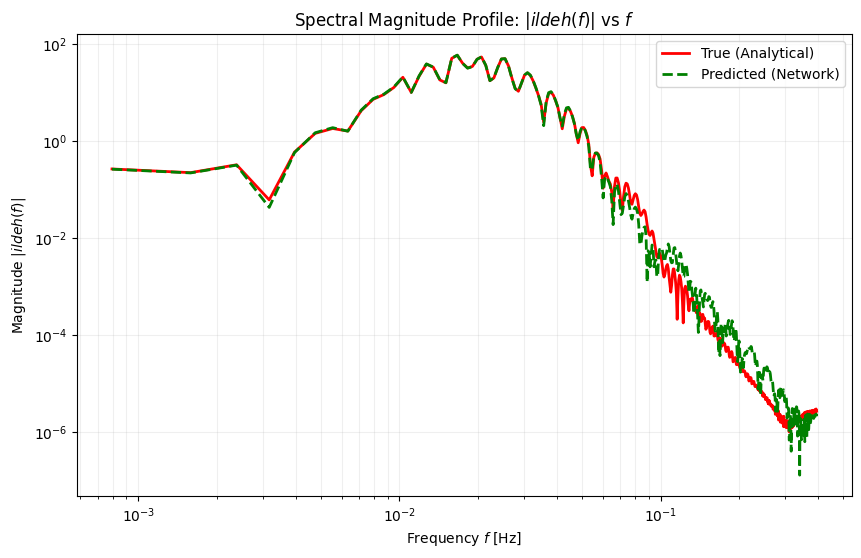

In [61]:
dt_plot = assert_uniform_time(t_test).detach().item()
h_true = torch.complex(h_plus_true[0], h_cross_true[0])
h_pred = torch.complex(hp_trained, hc_trained)
plotSpectralDiagnostic(h_true, h_pred, dt=dt_plot)

In [62]:
def plotGeodesicProjections(soln_true, soln_pred, a_spin):
    """Visualizes the 'dance' in 3D and 2D projections [user history]."""
    # Use existing BL2Cartesian function for consistency [2]
    x_t, y_t, z_t = BoyerLindquist2Cartesian(soln_true[:,1], soln_true[:,2], soln_true[:,3], a_spin)
    x_p, y_p, z_p = BoyerLindquist2Cartesian(soln_pred[:,1], soln_pred[:,2], soln_pred[:,3], a_spin)

    fig = plt.figure(figsize=(15, 10))

    # 3D View
    ax1 = fig.add_subplot(221, projection='3d')
    ax1.plot(x_t.detach(), y_t.detach(), z_t.detach(), 'r-', label='True')
    ax1.plot(x_p.detach(), y_p.detach(), z_p.detach(), 'g--', label='Pred')
    ax1.set_title("3D Geodesic Reconstruction")

    # Projections
    projections = [(222, x_t, y_t, x_p, y_p, "X-Y (Precession)"),
                   (223, x_t, z_t, x_p, z_p, "X-Z (Wobble)"),
                   (224, y_t, z_t, y_p, z_p, "Y-Z (Inclination)")]

    for pos, d1_t, d2_t, d1_p, d2_p, title in projections:
        ax = fig.add_subplot(pos)
        ax.plot(d1_t.detach(), d2_t.detach(), 'r-', alpha=0.6)
        ax.plot(d1_p.detach(), d2_p.detach(), 'g--', linewidth=2)
        ax.set_title(title)
        ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()


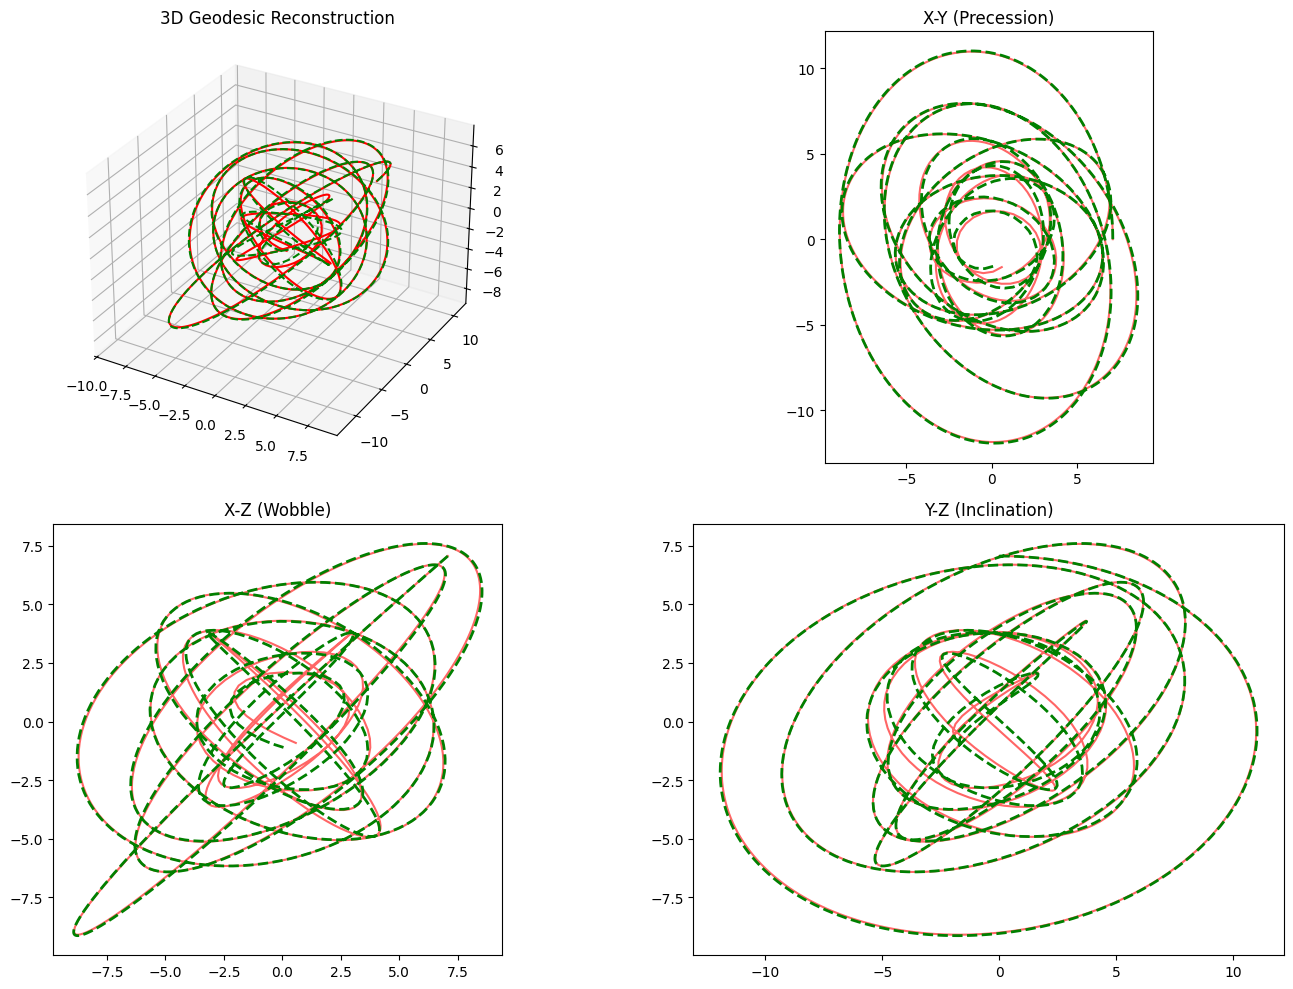

In [63]:
plotGeodesicProjections(trajectory_gate, traj, a_true)

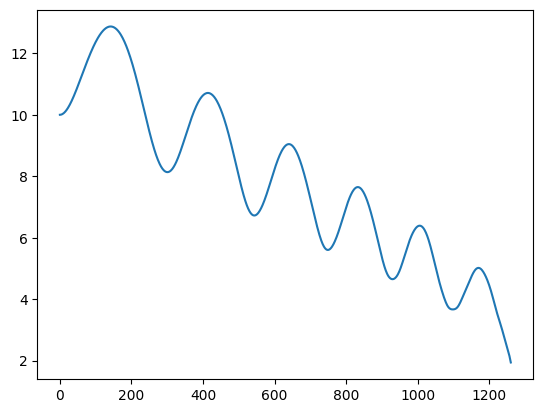

In [64]:
plt.plot(t_test, traj[:,1].detach().numpy())

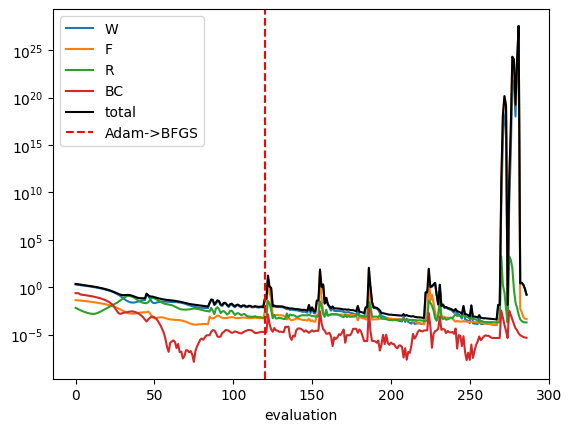

In [65]:
for history, label in [
    (waveform_loss_history, 'W'),
    (frequency_loss_history, 'F'),
    (ricci_loss_history, 'R'),
    (boundaryCondition_loss_history, 'BC')
]:
  plt.plot(history, label = label)

plt.plot(loss_history, 'k', label='total')
plt.axvline(
    adam_end,
    color="red",
    linestyle="--",
    label="Adam->BFGS"
)
plt.yscale('log')
plt.xlabel('evaluation')
plt.legend()

Stride of 10 Elements Comparison:

Time: tensor([   0.0000,   12.6126,   25.2252,   37.8378,   50.4504,   63.0631,
          75.6757,   88.2883,  100.9009,  113.5135,  126.1261,  138.7387,
         151.3513,  163.9640,  176.5766,  189.1892,  201.8018,  214.4144,
         227.0270,  239.6396,  252.2522,  264.8649,  277.4775,  290.0901,
         302.7027,  315.3153,  327.9279,  340.5405,  353.1531,  365.7657,
         378.3784,  390.9910,  403.6036,  416.2162,  428.8288,  441.4414,
         454.0540,  466.6667,  479.2793,  491.8919,  504.5045,  517.1171,
         529.7297,  542.3423,  554.9550,  567.5676,  580.1802,  592.7928,
         605.4054,  618.0180,  630.6307,  643.2433,  655.8559,  668.4685,
         681.0811,  693.6937,  706.3063,  718.9189,  731.5316,  744.1442,
         756.7568,  769.3694,  781.9820,  794.5946,  807.2072,  819.8198,
         832.4324,  845.0450,  857.6577,  870.2703,  882.8829,  895.4955,
         908.1081,  920.7207,  933.3333,  945.9460,  958.5586,  971.171

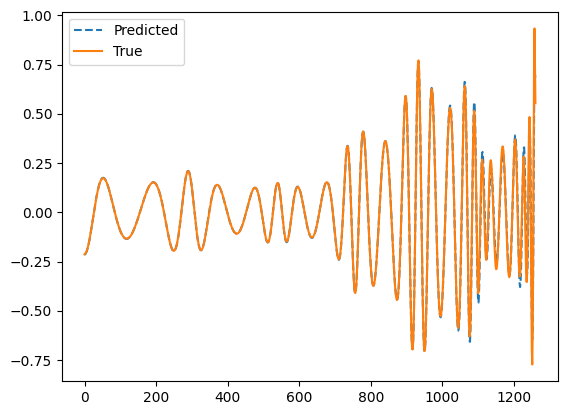

In [66]:
t_final_plot = len(t_test)

plt.plot(t_test.detach()[0:t_final_plot], hp_trained.detach()[0:t_final_plot], label = "Predicted", linestyle='dashed')
plt.plot(t_test.detach()[0:t_final_plot], h_plus_true[0][0:t_final_plot], label = "True", linestyle = "solid")

print("Stride of 10 Elements Comparison:\n")
print("Time:", t_test.detach()[::10])
print("hp_trained.detach:", hp_trained.detach()[::10])
print("h_plus_true:", h_plus_true[0][::10])

plt.legend()

In [67]:
from matplotlib.lines import Line2D

def compare_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, math.pi/20]

  # fig, axes = plt.subplots(2, 3)

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_by_component = []
  true_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T
    pred_by_component.append(pred_i)
    true_by_component.append(true_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    ax.set_title(f"${components[i]}$ Component")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    figs.append(fig)

  return figs, pred_by_component, true_by_component

def angular_comparison_metrics(NN):
  M, a = 1.0, a_true
  r_plus = M + math.sqrt(M**2 - a**2)

  r_vals = np.linspace(2, ra_true, 20)
  θ_vals = [math.pi/2, math.pi/3, math.pi/4, 0]

  figs = []
  colors = ['C0', 'C1', 'C2', 'C3']

  components = ["g_{tt}", "g_{rr}", "g_{θθ}", "g_{ϕϕ}", "g_{tϕ}"]
  component_index = [(0,0), (1,1), (2,2), (3,3), (0,3)]

  pred_diff_by_component = []
  true_diff_by_component = []

  for i in range(len(components)):
    fig, ax = plt.subplots(figsize=(8,6), dpi=150)
    true_metric, pred_metric = [], []
    for θ in θ_vals:
      for r in r_vals:
        r = torch.tensor(r, dtype = next(NN.parameters()).dtype)
        θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)

        true_g = g_Kerr(r, θ)[component_index[i]]
        pred_g = metric_from_network(NN, r, θ)[component_index[i]]

        pred_metric.append(pred_g)
        true_metric.append(true_g)

    pred_i = torch.stack(pred_metric).reshape(4,20).T
    true_i = torch.stack(true_metric).reshape(4,20).T

    pred_diff_i = pred_i - pred_i[:, 0:1]
    true_diff_i = true_i - true_i[:, 0:1]

    pred_diff_by_component.append(pred_diff_i)
    true_diff_by_component.append(true_diff_i)

    for θ_idx in range(len(θ_vals)):
      ax.plot(r_vals, pred_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='dashed')
      ax.plot(r_vals, true_diff_i[:, θ_idx].detach(), color=colors[θ_idx], linestyle='solid')

    ax.set_title(f"${components[i]}$ Component Angular Difference")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(components[i])
    handles = [Line2D([0], [0], color = colors[i], label=f"θ={round(θ_vals[i],2)}") for i in range(len(θ_vals))]
    handles += [
        Line2D([0], [0], color='k', linestyle='dashed', label='Predicted'),
        Line2D([0], [0], color='k', linestyle='solid', label='True')
    ]
    ax.legend(handles=handles)
    figs.append(fig)

  return figs, pred_diff_by_component, true_diff_by_component

/tmp/ipykernel_58641/3873156370.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


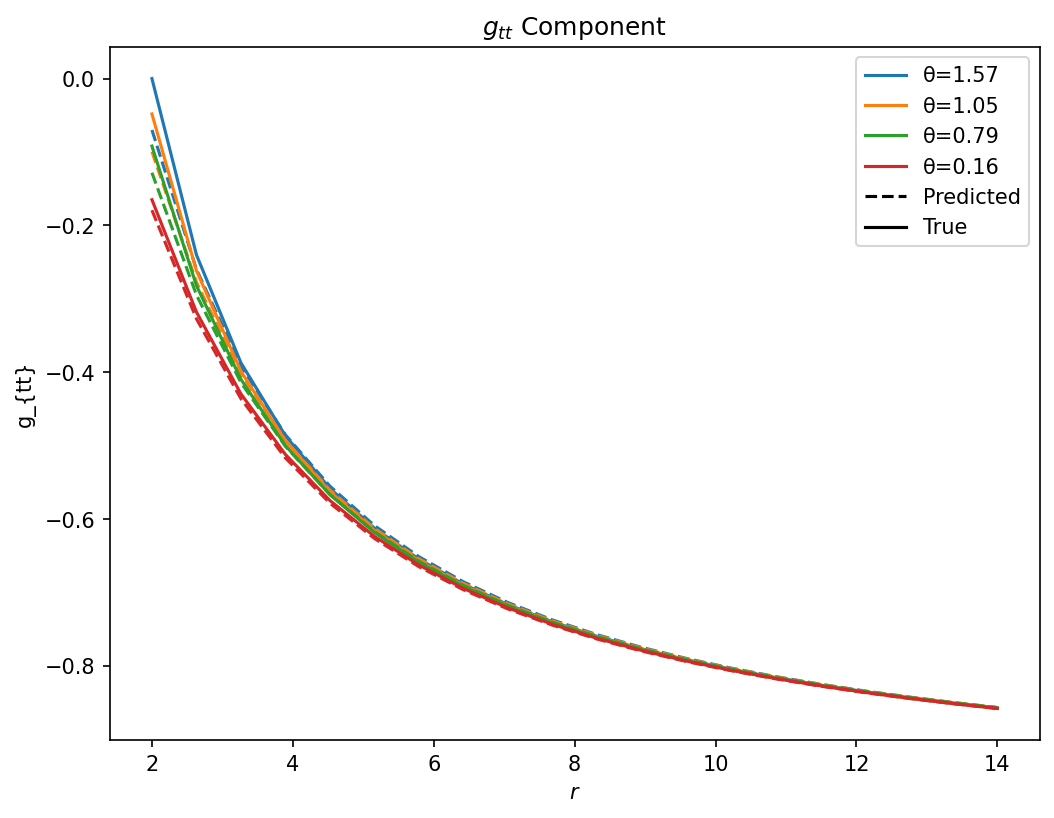

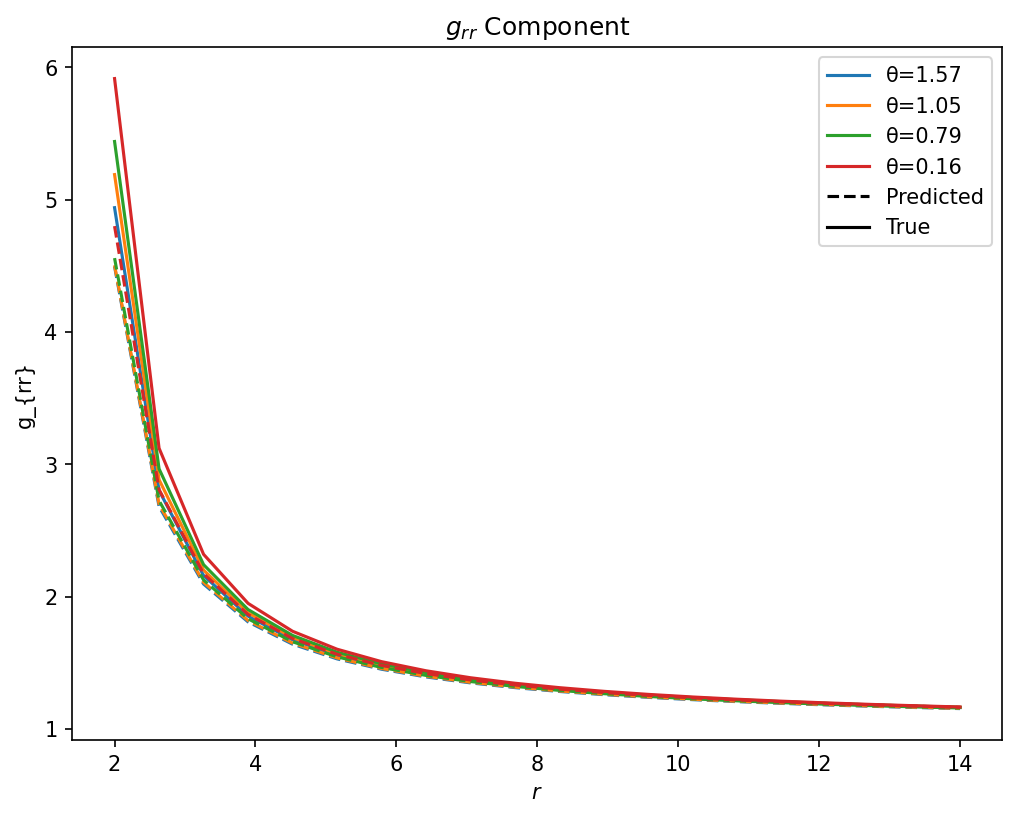

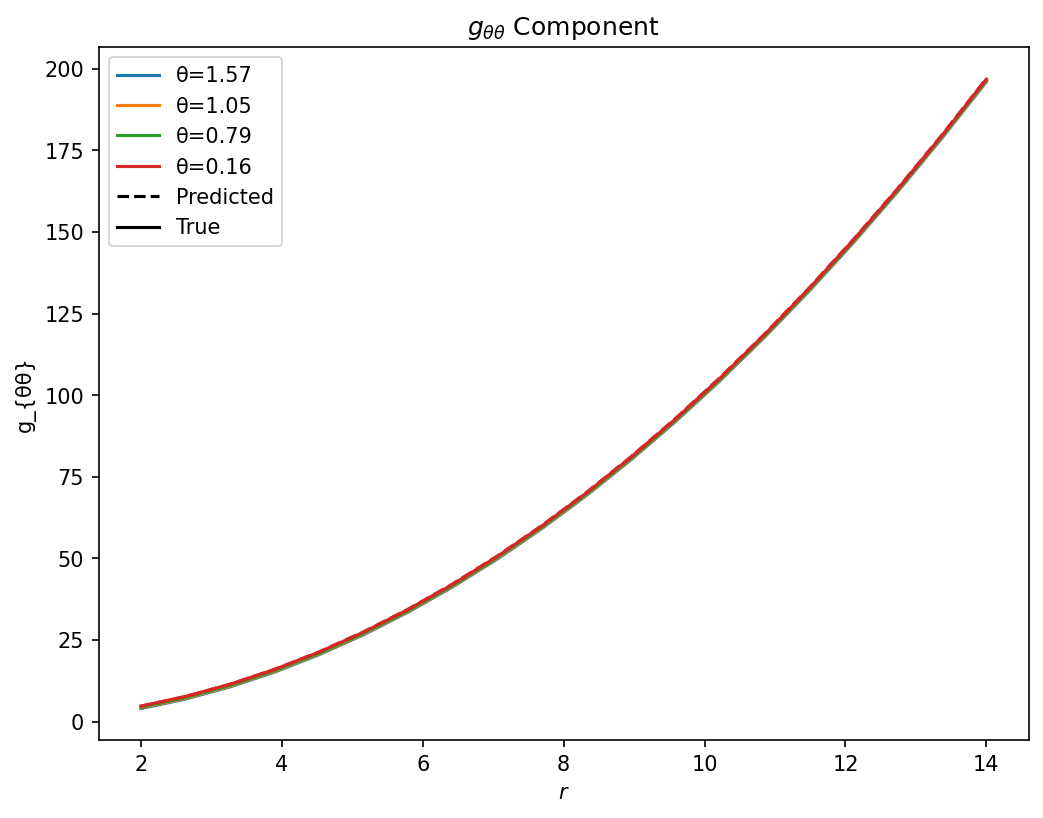

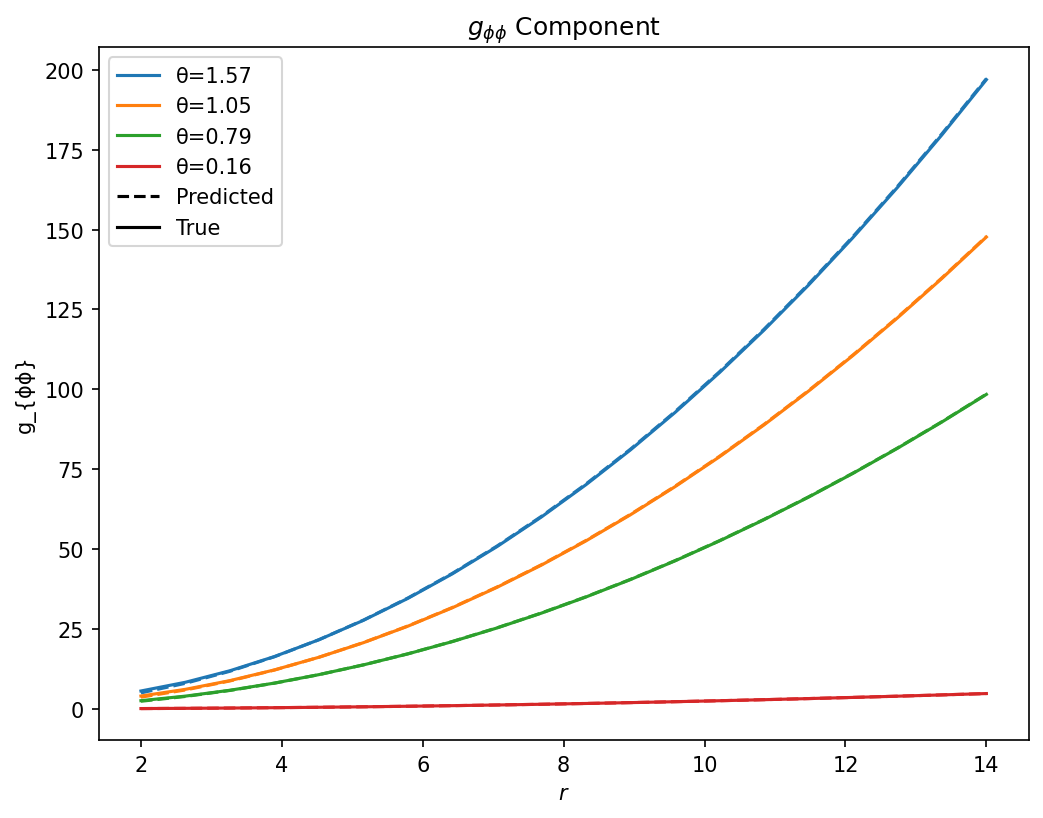

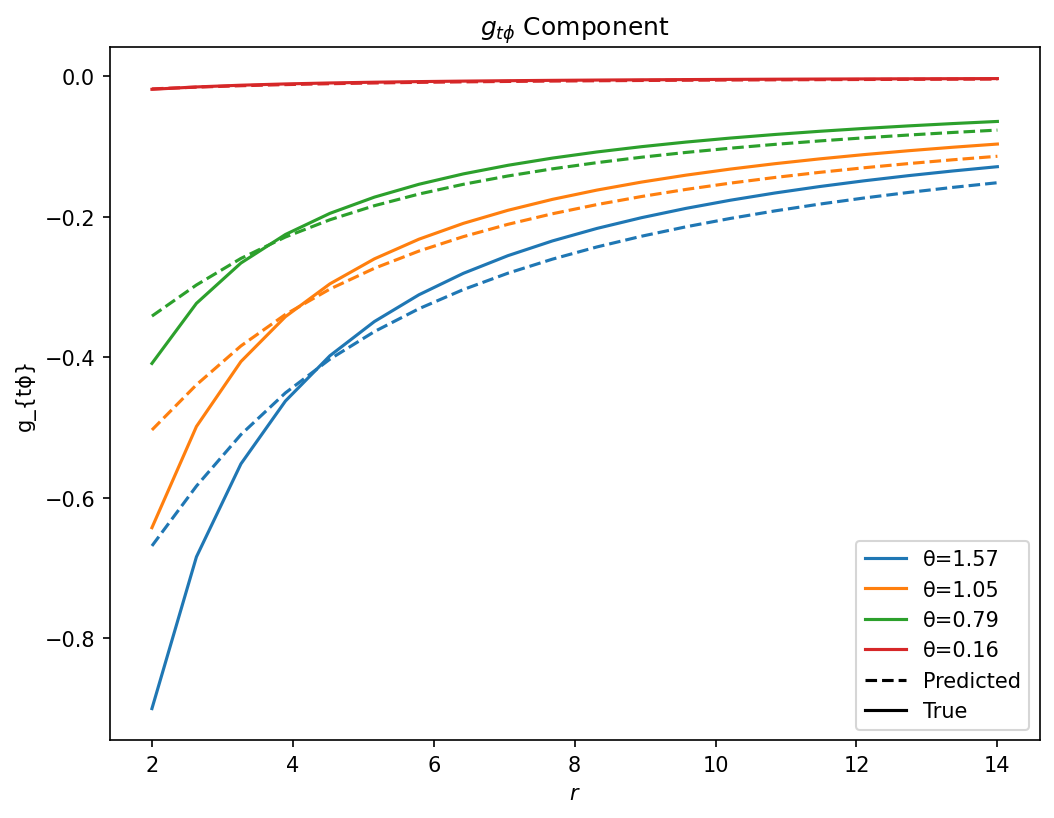

In [68]:
fig, a, b = compare_metrics(net)

/tmp/ipykernel_58641/3873156370.py:79: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  θ = torch.tensor(θ, dtype = next(NN.parameters()).dtype)


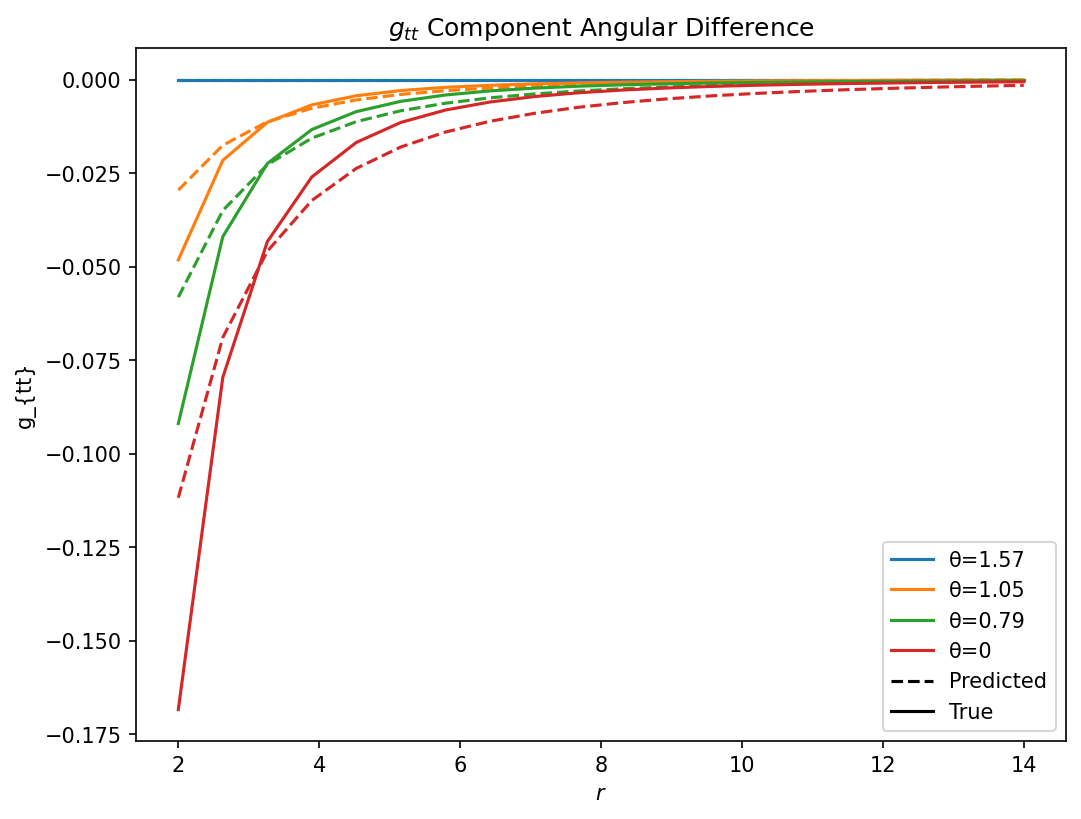

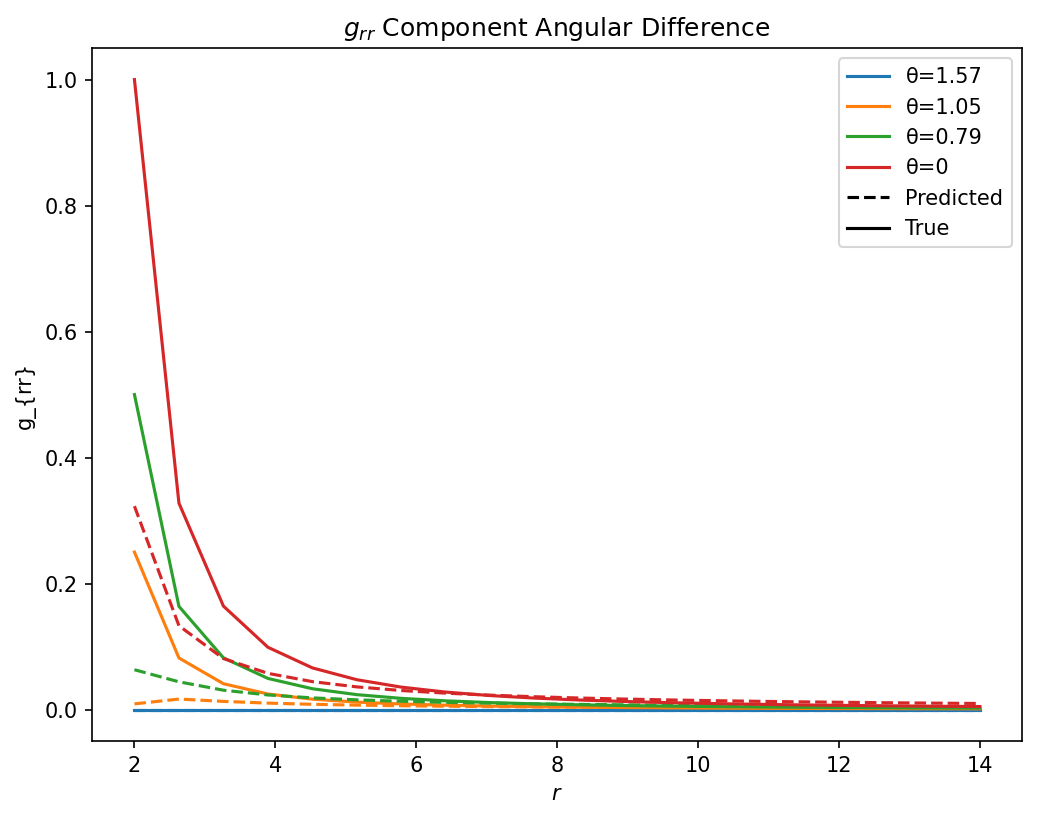

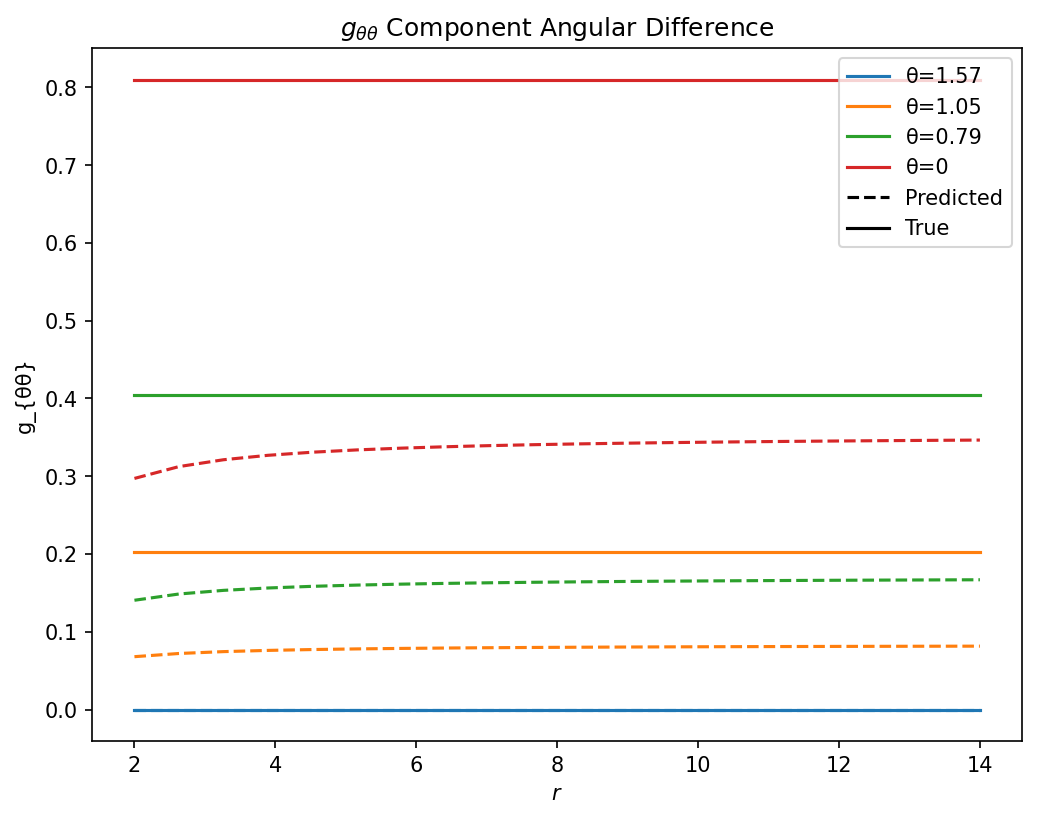

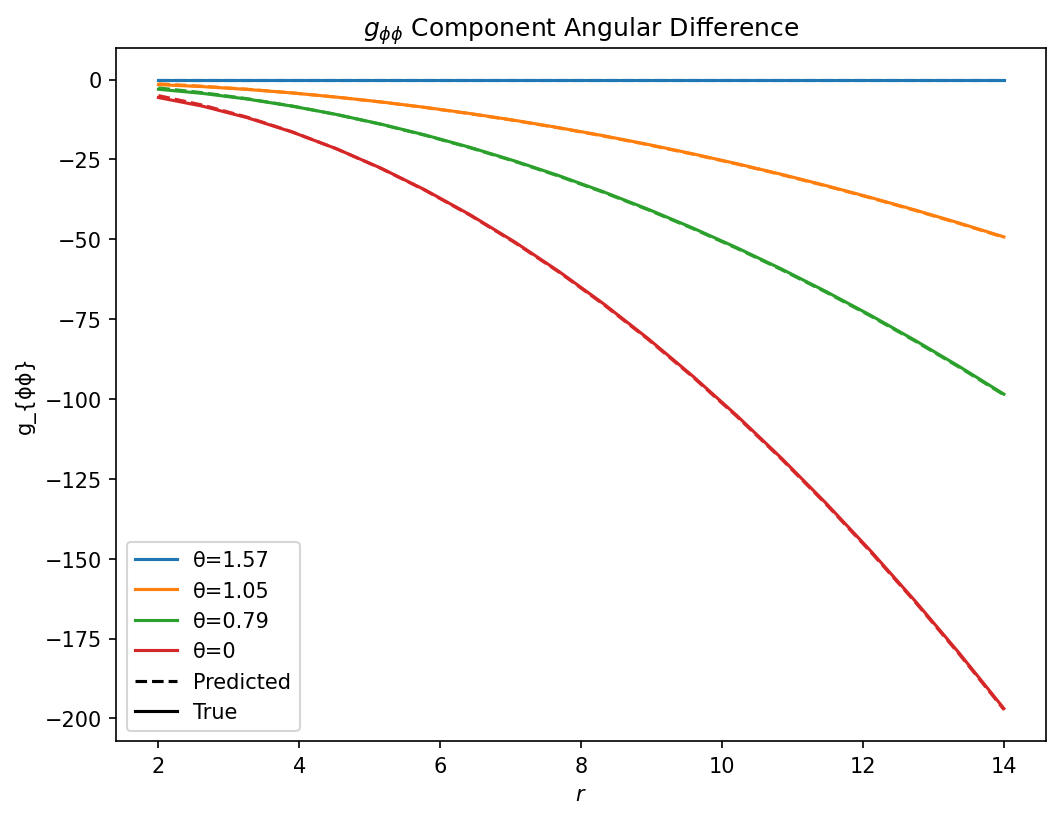

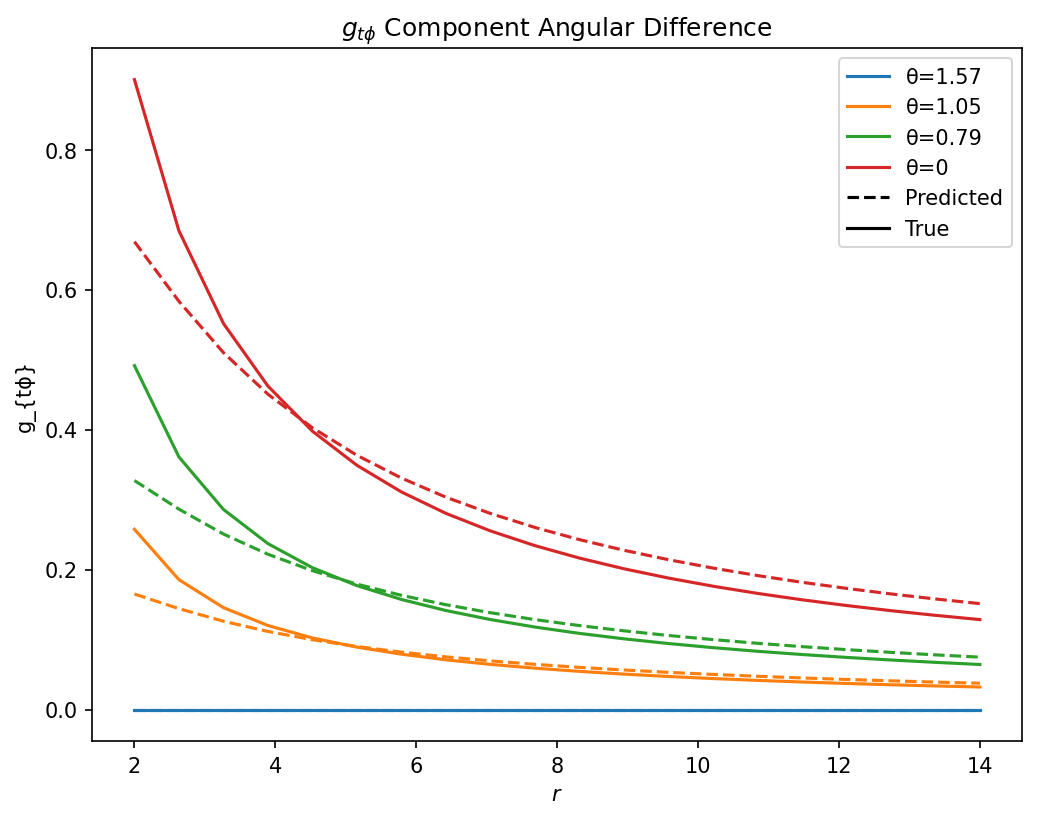

In [69]:
def percent_diff(pred, true):
  return 100 * abs(pred - true) / abs(true)

b, c, d = angular_comparison_metrics(net)

In [70]:
from prettytable import PrettyTable

def print_metric_error_table(network, r_grid = [2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 20]):

    θ_grid = [π/20, π/4, π/3, π/2]

    components = {
        "g_tt": (0,0),
        "g_rr": (1,1),
        "g_θθ": (2,2),
        "g_ϕϕ": (3,3),
        "g_tϕ": (0,3),
    }

    errors = {name: [] for name in components}
    param = next(network.parameters())

    with torch.no_grad():
      for r in r_grid:
        pred_at_r = []
        true_at_r = []

        for θ in θ_grid:
          r_t = torch.tensor(r, dtype = param.dtype)
          θ_t = torch.tensor(θ, dtype = param.dtype)

          pred_at_r.append(metric_from_network(network, r_t, θ_t))
          true_at_r.append(g_Kerr(r_t, θ_t))

        pred_at_r = torch.stack(pred_at_r)
        true_at_r = torch.stack(true_at_r)

        for name, (μ, ν) in components.items():
          error = rel_L2_error(
              pred_at_r[:, μ, ν],
              true_at_r[:, μ, ν]
          )

          errors[name].append(error.item())

    table = PrettyTable()
    table.title = "Metric Relative L2 Error Across θ (%)"
    table.field_names = [
        "Component",
        *[f"r={r:g}" for r in r_grid]
    ]
    table.float_format = ".2"

    for name in components:
      table.add_row([name, *errors[name]])

    print(table)
    return table, errors


In [71]:
metric_table, metric_errors = print_metric_error_table(net)

+-------------------------------------------------------------------------------------------------------+
|                                 Metric Relative L2 Error Across θ (%)                                 |
+-----------+-------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+
| Component |  r=2  | r=3  | r=4  | r=5  | r=6  |  r=7  |  r=8  |  r=10 |  r=12 |  r=14 |  r=16 |  r=20 |
+-----------+-------+------+------+------+------+-------+-------+-------+-------+-------+-------+-------+
|    g_tt   | 48.83 | 2.13 | 0.49 | 0.44 | 0.37 |  0.29 |  0.23 |  0.15 |  0.10 |  0.07 |  0.05 |  0.03 |
|    g_rr   | 15.23 | 5.80 | 3.30 | 2.21 | 1.64 |  1.29 |  1.06 |  0.78 |  0.61 |  0.51 |  0.43 |  0.34 |
|    g_θθ   |  6.10 | 3.53 | 2.24 | 1.54 | 1.12 |  0.85 |  0.66 |  0.44 |  0.31 |  0.23 |  0.18 |  0.12 |
|    g_ϕϕ   |  9.65 | 2.01 | 0.27 | 0.19 | 0.30 |  0.31 |  0.29 |  0.23 |  0.18 |  0.15 |  0.12 |  0.08 |
|    g_tϕ   | 23.62 | 8.98 | 1.59 | 4.34 | 7.7

# Save Results

In [72]:
torch.save(
    net.state_dict(),
    "/content/sonar_v11_0.pt"
)

In [73]:
# Optional extra continuation. Disabled so Run All has one controlled experiment.
RUN_EXTRA_BFGS = False

if RUN_EXTRA_BFGS:
  bfgs_start_time = time.time()
  result_continued = run_bfgs_stage(window=1000, maxiter=100)
  result = result_continued


In [74]:
if RUN_EXTRA_BFGS:
  t_test = t_full
  h_plus_true = hp_full
  h_cross_true = hc_full

  final_total_2, final_w_2, final_r_2, final_f_2, final_b_2, final_roots_2 = loss(net)
  log_diagnostics(
      net, final_total_2, final_w_2, final_r_2, final_f_2, final_b_2,
      final_roots_2, n + result_continued.nit, time.time() - bfgs_start_time
  )
